# Tiền xử lý dữ liệu văn bản - IMDB Movie Reviews Dataset

## Nội dung:
- **Part A**: Pipeline chuẩn hóa văn bản (chuyển về chữ thường, loại bỏ HTML/URL/mention/hashtag, loại bỏ ký tự đặc biệt và số, chuẩn hóa khoảng trắng). Với mỗi bước, báo cáo **tỉ lệ từ vựng thay đổi** và tác động đến **phân phối độ dài văn bản**.
- **Part B**: So sánh chiến lược tokenization: word-level (NLTK, spaCy), sentence-level, character-level, và subword (BPE bằng thư viện `tokenizers` của HuggingFace). Với mỗi chiến lược, báo cáo: (i) kích thước từ vựng; (ii) tỉ lệ OOV trên tập test; (iii) độ dài chuỗi token trung bình.
- **Part C**: Bỏ stop words + so sánh vocab, MI, hiệu năng Naive Bayes + thảo luận.
- **Part D**: Stemming vs Lemmatization (Porter, Snowball, WordNet) + collision rate & Logistic Regression (5-fold CV).
- **Part E**: Vector hóa (BoW, TF-IDF n-gram, Word2Vec) + số chiều, sparsity, cosine similarity, t-SNE, silhouette score.
- **Part F**: Sentence Transformer vs TF-IDF + clustering (K-Means), phân loại (Linear SVM) + giải thích ngữ nghĩa.

## Library Installation and Configuration

In [1]:
import re
import regex
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, silhouette_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Đường dẫn dữ liệu
DATA_PATH = r'..\data\raw\text\IMDB Dataset.csv'

## Load Data

In [2]:
df = pd.read_csv(DATA_PATH)

print('5 mẫu đầu tiên:')
df.head()

5 mẫu đầu tiên:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
## Part A - Pipeline chuẩn hóa văn bản

### A.1 Lý thuyết

Pipeline chuẩn hóa văn bản (text normalization pipeline) là quá trình biến đổi dữ liệu văn bản thô thành dạng sạch, nhất quán hơn để phục vụ các bước phân tích và mô hình hóa tiếp theo. Các bước chính sẽ cài đặt bao gồm:

1. **Chuyển về chữ thường (Lowercasing):** Giảm kích thước từ vựng bằng cách gộp các biến thể chữ hoa/thường.
2. **Loại bỏ HTML tags:** Dữ liệu web thường chứa các thẻ HTML cần được loại bỏ.
3. **Loại bỏ URL/Mention/Hashtag:** Loại bỏ các thành phần không mang thông tin ngữ nghĩa quan trọng.
4. **Loại bỏ ký tự đặc biệt và số (có điều kiện):** Loại bỏ dấu câu, ký tự đặc biệt, và tùy chọn loại bỏ số.
5. **Chuẩn hóa khoảng trắng (Whitespace normalization):** Gộp nhiều khoảng trắng liên tiếp thành một khoảng trắng duy nhất.

#### Đo lường
- **Tỉ lệ từ vựng thay đổi:** So sánh kích thước từ vựng trước và sau mỗi bước.
- **Phân phối độ dài văn bản:** Thống kê số từ của mỗi văn bản trước và sau mỗi bước.

### A.2 Code cài đặt

#### Định nghĩa các hàm trong Pipeline

In [3]:
def step_lowercase(text):
    """Bước 1: Chuyển toàn bộ văn bản về chữ thường."""
    return text.lower()

def step_remove_html(text):
    """Bước 2: Loại bỏ các thẻ HTML và HTML entities (vd: &amp;, &nbsp;, &lt;...)."""
    text = re.sub(r'<[^>]+>', ' ', text)           # Xóa thẻ HTML
    text = re.sub(r'&[a-z]{2,6};', ' ', text)      # Xóa HTML entities dạng &amp; &nbsp;
    text = re.sub(r'&#\d+;', ' ', text)            # Xóa HTML entities dạng &#160;
    return text

def step_remove_url_mention_hashtag(text):
    """Bước 3: Loại bỏ URL, mention, và hashtag."""
    text = re.sub(r'(?:https?://|ftp://|//)\S+|www\.\S+', ' ', text)  # URL
    text = re.sub(r'@\w+', ' ', text)                                   # Mention
    text = re.sub(r'#\w+', ' ', text)                                   # Hashtag
    return text

def step_remove_special_chars_and_numbers(text):
    """
    Bước 4: Loại bỏ ký tự đặc biệt và số (có điều kiện).
    - Giữ lại mọi chữ cái Unicode (\p{L}): Latin, có dấu, ký tự nước ngoài...
    - Giữ lại số nếu dính liền với chữ cái (vd: covid19, 4g, mp3).
    - Loại bỏ số đứng độc lập.
    """
    # Xóa số đứng độc lập, giữ số dính chữ
    text = regex.sub(r'(?<!\p{L})\d+(?!\p{L})', ' ', text)
    # Xóa ký tự đặc biệt, giữ chữ cái Unicode + số còn lại + khoảng trắng
    text = regex.sub(r'[^\p{L}0-9\s]', ' ', text)
    return text

def step_normalize_whitespace(text):
    """Bước 5: Chuẩn hóa khoảng trắng (gộp nhiều khoảng trắng thành 1, loại bỏ đầu/cuối)."""
    return re.sub(r'\s+', ' ', text).strip()
    
pipeline_steps = [
    ('Lowercasing', step_lowercase),
    ('Remove HTML', step_remove_html),
    ('Remove URL/Mention/Hashtag', step_remove_url_mention_hashtag),
    ('Remove Special Chars & Numbers', step_remove_special_chars_and_numbers),
    ('Normalize Whitespace', step_normalize_whitespace),
]

print(f'Pipeline gồm {len(pipeline_steps)} bước:')
for i, (name, _) in enumerate(pipeline_steps, 1):
    print(f'  {i}. {name}')

Pipeline gồm 5 bước:
  1. Lowercasing
  2. Remove HTML
  3. Remove URL/Mention/Hashtag
  4. Remove Special Chars & Numbers
  5. Normalize Whitespace


#### Các hàm đo lường

In [4]:
def compute_vocab(series):
    """Tính từ vựng (vocabulary) từ một cột văn bản."""
    all_words = []
    for text in series:
        all_words.extend(str(text).split())
    return set(all_words)

def compute_word_counts(series):
    """Tính số từ trong mỗi văn bản."""
    return series.apply(lambda x: len(str(x).split()))

def report_step(step_name, prev_vocab, curr_vocab, prev_word_counts, curr_word_counts):
    """In báo cáo sau mỗi bước pipeline."""
    prev_size = len(prev_vocab)
    curr_size = len(curr_vocab)
    change_pct = (curr_size - prev_size) / prev_size * 100 if prev_size > 0 else 0
    
    print(f'\n--- Bước: {step_name} ')
    print(f'  Từ vựng trước: {prev_size:,} | Từ vựng sau: {curr_size:,} | Thay đổi: {change_pct:+.2f}%')
    print(f'  Độ dài TB trước: {prev_word_counts.mean():.2f} | Độ dài TB sau: {curr_word_counts.mean():.2f}')
    print(f'  Độ dài Median trước: {prev_word_counts.median():.1f} | Độ dài Median sau: {curr_word_counts.median():.1f}')
    
    return {
        'step': step_name,
        'vocab_before': prev_size,
        'vocab_after': curr_size,
        'vocab_change_pct': change_pct,
        'mean_len_before': prev_word_counts.mean(),
        'mean_len_after': curr_word_counts.mean(),
        'median_len_before': prev_word_counts.median(),
        'median_len_after': curr_word_counts.median(),
    }

#### Chạy pipeline

In [5]:
# Bắt đầu từ dữ liệu gốc
current_texts = df['review'].copy()
reports = []

# Lưu trạng thái ban đầu
prev_vocab = compute_vocab(current_texts)
prev_word_counts = compute_word_counts(current_texts)
print(f'TRẠNG THÁI BAN ĐẦU')
print(f'  Kích thước từ vựng: {len(prev_vocab):,}')
print(f'  Độ dài TB: {prev_word_counts.mean():.2f} từ')
print(f'  Độ dài Median: {prev_word_counts.median():.1f} từ')

# Chạy từng bước pipeline
for step_name, step_func in pipeline_steps:
    current_texts = current_texts.apply(step_func)
    
    curr_vocab = compute_vocab(current_texts)
    curr_word_counts = compute_word_counts(current_texts)
    
    report = report_step(step_name, prev_vocab, curr_vocab, prev_word_counts, curr_word_counts)
    reports.append(report)
    
    prev_vocab = curr_vocab
    prev_word_counts = curr_word_counts

# Lưu kết quả pipeline vào DataFrame
df['review_cleaned'] = current_texts
report_df = pd.DataFrame(reports)
report_df

TRẠNG THÁI BAN ĐẦU
  Kích thước từ vựng: 438,729
  Độ dài TB: 231.16 từ
  Độ dài Median: 173.0 từ

--- Bước: Lowercasing 
  Từ vựng trước: 438,729 | Từ vựng sau: 390,931 | Thay đổi: -10.89%
  Độ dài TB trước: 231.16 | Độ dài TB sau: 231.16
  Độ dài Median trước: 173.0 | Độ dài Median sau: 173.0

--- Bước: Remove HTML 
  Từ vựng trước: 390,931 | Từ vựng sau: 365,391 | Thay đổi: -6.53%
  Độ dài TB trước: 231.16 | Độ dài TB sau: 228.87
  Độ dài Median trước: 173.0 | Độ dài Median sau: 171.0

--- Bước: Remove URL/Mention/Hashtag 
  Từ vựng trước: 365,391 | Từ vựng sau: 365,087 | Thay đổi: -0.08%
  Độ dài TB trước: 228.87 | Độ dài TB sau: 228.86
  Độ dài Median trước: 171.0 | Độ dài Median sau: 171.0

--- Bước: Remove Special Chars & Numbers 
  Từ vựng trước: 365,087 | Từ vựng sau: 100,378 | Thay đổi: -72.51%
  Độ dài TB trước: 228.86 | Độ dài TB sau: 234.09
  Độ dài Median trước: 171.0 | Độ dài Median sau: 175.0

--- Bước: Normalize Whitespace 
  Từ vựng trước: 100,378 | Từ vựng sau: 100,3

,step,vocab_before,vocab_after,vocab_change_pct,mean_len_before,mean_len_after,median_len_before,median_len_after
0,Lowercasing,438729,390931,-10.894653,231.15694,231.15694,173.0,173.0
1,Remove HTML,390931,365391,-6.533122,231.15694,228.86624,173.0,171.0
2,Remove URL/Mention/Hashtag,365391,365087,-0.083199,228.86624,228.85968,171.0,171.0
3,Remove Special Chars & Numbers,365087,100378,-72.505732,228.85968,234.08678,171.0,175.0
4,Normalize Whitespace,100378,100378,0.000000,234.08678,234.08678,175.0,175.0


#### Trực quan hóa

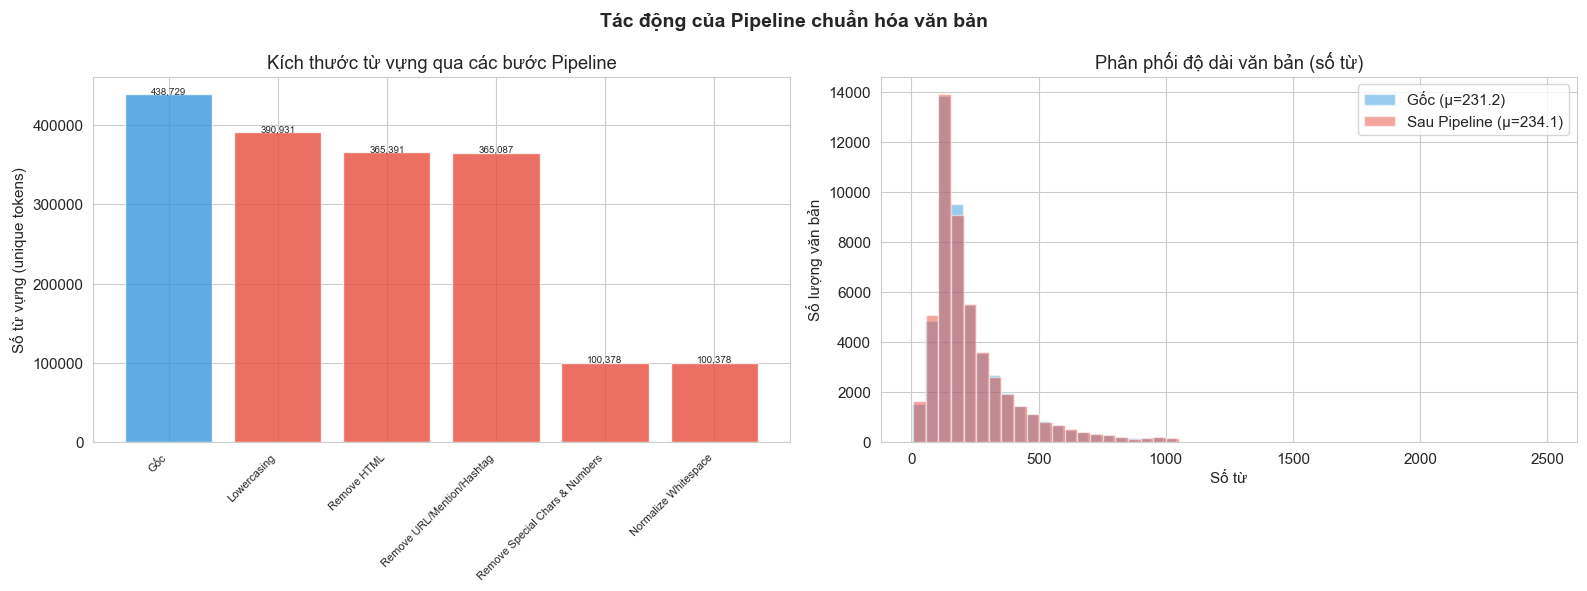

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tác động của Pipeline chuẩn hóa văn bản', fontsize=14, fontweight='bold')

# Biểu đồ 1: Kích thước từ vựng qua từng bước
step_labels = ['Gốc'] + [r['step'] for r in reports]
vocab_sizes = [reports[0]['vocab_before']] + [r['vocab_after'] for r in reports]

ax1 = axes[0]
ax1.bar(range(len(vocab_sizes)), vocab_sizes, color=['#3498db'] + ['#e74c3c']*len(reports), alpha=0.8)
ax1.set_xticks(range(len(step_labels)))
ax1.set_xticklabels(step_labels, rotation=45, ha='right', fontsize=8)
ax1.set_title('Kích thước từ vựng qua các bước Pipeline')
ax1.set_ylabel('Số từ vựng (unique tokens)')
for i, v in enumerate(vocab_sizes):
    ax1.text(i, v + 500, f'{v:,}', ha='center', fontsize=7)

#  Biểu đồ 2: Phân phối độ dài văn bản (trước vs sau) 
ax2 = axes[1]
original_wc = compute_word_counts(df['review'])
cleaned_wc = compute_word_counts(df['review_cleaned'])
ax2.hist(original_wc, bins=50, alpha=0.5, color='#3498db', label=f'Gốc (μ={original_wc.mean():.1f})', edgecolor='white')
ax2.hist(cleaned_wc, bins=50, alpha=0.5, color='#e74c3c', label=f'Sau Pipeline (μ={cleaned_wc.mean():.1f})', edgecolor='white')
ax2.set_title('Phân phối độ dài văn bản (số từ)')
ax2.set_xlabel('Số từ')
ax2.set_ylabel('Số lượng văn bản')
ax2.legend()

plt.tight_layout()
plt.show()

### A.3 Phân tích kết quả

* **Bước Lowercasing:**
    * **Từ vựng:** Giảm từ **438.729** xuống **390.931** (thay đổi **-10.89%**). 
    * **Tác động độ dài văn bản:** Không làm thay đổi phân bố độ dài văn bản. Bước này chỉ đơn thuần gộp các biến thể chữ hoa và chữ thường của cùng một từ về một định dạng chung.

* **Bước Remove HTML:**
    * **Từ vựng:** Giảm từ **390.931** xuống **365.391** (thay đổi **-6.53%**).
    * **Tác động độ dài văn bản:** Làm giảm nhẹ phân bố độ dài văn bản. Việc các token rác sinh ra từ cú pháp HTML (như `<br`, `/>`) bị xóa bỏ khiến cho tổng số lượng token cấu thành văn bản ngắn lại.

* **Bước Remove URL/Mention/Hashtag:**
    * **Từ vựng:** Giảm từ **365.391** xuống **365.087** (thay đổi rất nhỏ, chỉ **-0.08%**).
    * **Tác động độ dài văn bản:** Hầu như không có sự xê dịch về độ dài văn bản. Điều này phản ánh đặc thù của tập dữ liệu này chứa rất ít các liên kết, thẻ tag hay lượt nhắc đến (mentions) so với các dữ liệu mạng xã hội.

* **Bước Remove Special Chars & Numbers:**
    * **Từ vựng:** Giảm đột phá từ **365.087** xuống chỉ còn **100.378** (thay đổi sâu tới **-72.51%**).
    * **Tác động độ dài văn bản:** Phân bố độ dài văn bản lại có sự gia tăng nhẹ. Việc loại bỏ các ký tự đặc biệt có thể đã làm thay đổi hành vi của bộ tách từ (tokenizer), khiến các từ liền kề (vốn bị ngăn cách bởi ký tự đặc biệt) bị gộp lại hoặc thay đổi cấu trúc đếm token. Bước này đóng vai trò lớn nhất trong việc rút gọn không gian đặc trưng.

* **Bước Normalize Whitespace:**
    * **Từ vựng:** Giữ nguyên ở mức **100.378** (thay đổi **+0.00%**).
    * **Tác động độ dài văn bản:** Không có sự thay đổi về độ dài. Quá trình dọn dẹp các khoảng trắng thừa, dấu tab hay ngắt dòng chỉ giúp văn bản hiển thị sạch hơn mà không ảnh hưởng đến số lượng token thực tế.

**Tổng kết:** Toàn bộ pipeline xử lý đã hoạt động hiệu quả, thu gọn kích thước từ vựng xuống chỉ còn chưa tới 1/4 so với ban đầu. Quá trình này giúp loại bỏ phần lớn lượng nhiễu (HTML, ký tự vô nghĩa, con số) và chuẩn hóa dữ liệu ở mức tối ưu để đưa vào huấn luyện mô hình học máy.

---

## Part B - So sánh chiến lược Tokenization

### B.1 Lý thuyết

Tokenization là bước chia văn bản thành các đơn vị nhỏ hơn (tokens) để phục vụ xử lý ngôn ngữ tự nhiên. Các chiến lược phổ biến:

1. **Word-level (NLTK):** Sử dụng `word_tokenize` của NLTK để tách từ dựa trên quy tắc ngôn ngữ.
2. **Sentence-level:** Tách văn bản thành các câu (sử dụng `sent_tokenize` NLTK).
3. **Character-level:** Mỗi ký tự là một token.
4. **Subword - BPE (HuggingFace tokenizers):** Thuật toán Byte Pair Encoding (BPE) học các subword phổ biến, cân bằng giữa word-level và character-level.

#### Thuật toán BPE:

1. **Khởi tạo:** Chia nhỏ tất cả các từ trong ngữ liệu thành các ký tự đơn lẻ và thêm ký tự đặc biệt kết thúc từ (ví dụ: `</w>` hoặc `_`) để xác định ranh giới từ.
2. **Đếm tần suất:** Tìm cặp ký tự/subword liền kề (adjacent pair) xuất hiện nhiều nhất trong toàn bộ ngữ liệu.
3. **Hợp nhất (Merge):** Tạo một token mới bằng cách kết hợp cặp phổ biến nhất vừa tìm được và cập nhật từ vựng.
4. **Lặp lại:** Lặp lại bước 2 và 3 cho đến khi đạt được số lượng Merge (hợp nhất) hoặc kích thước từ vựng mục tiêu.

#### Công thức Toán học của BPE

#### Công thức tính Tần suất Cặp (Pair Frequency)

Cho ngữ liệu $C$, tần suất của một cặp liền kề $(t_i, t_{i+1})$ được tính bằng:

$$\text{Freq}(t_i, t_{i+1}) = \sum_{w \in C} \text{Count}(w) \times \text{Occurrences}(t_i, t_{i+1} \text{ in } w)$$

Trong đó:

* $w$ là một từ.
* $\text{Count}(w)$ là số lần từ $w$ xuất hiện trong ngữ liệu.

#### Quy tắc Hợp nhất (Merge Rule)

Sau khi tìm được cặp $(t_i, t_{i+1})$ có $\text{Freq}(t_i, t_{i+1})$ cao nhất, quy tắc hợp nhất là:

$$t_{new} = \text{Concat}(t_i, t_{i+1})$$

Token $t_{new}$ được thêm vào từ vựng, và mọi cặp $t_i, t_{i+1}$ trong ngữ liệu được thay thế bằng $t_{new}$.

#### Công thức Kích thước Từ vựng

Nếu bắt đầu với $|C|$ ký tự duy nhất và thực hiện $K$ lần hợp nhất, kích thước từ vựng cuối cùng sẽ là:

$$\text{Vocab Size} = |C| + K$$

*(Số lượng từ vựng thực tế có thể thấp hơn nếu một số hợp nhất không bao giờ xảy ra).*



#### Đo lường
- **(i) Kích thước từ vựng ($|V|$):**

   $$|V| = \text{count}(\text{unique tokens in Training Set})$$
- **(ii) Tỉ lệ OOV (Out-of-Vocabulary):**

   $$\text{OOV Rate} = \frac{\text{Number of tokens in Test set not in } V}{\text{Total tokens in Test set}} \times 100\%$$
- **(iii) Độ dài chuỗi trung bình ($\bar{L}$):**

   $$\bar{L} = \frac{1}{N} \sum_{i=1}^{N} \text{length}(\text{document}_i)$$

*(Với $N$ là số lượng văn bản trong tập dữ liệu).*

### B.2 Code cài đặt

#### Chia tập train/test

In [7]:
# Sử dụng cột review_cleaned (đã qua pipeline)
texts = df['review_cleaned'].values

# Chia train/test (80/20)
train_texts, test_texts = train_test_split(texts, test_size=0.2, random_state=42)

print(f'Số mẫu train: {len(train_texts)}')
print(f'Số mẫu test:  {len(test_texts)}')

Số mẫu train: 40000
Số mẫu test:  10000


#### Cài đặt 4 chiến lược Tokenization

In [8]:
# 1. Word-level (NLTK) 
def tokenize_nltk_word(texts):
    """Tokenize bằng NLTK word_tokenize."""
    return [word_tokenize(str(t)) for t in texts]

# 2. Sentence-level 
def tokenize_sentence(texts):
    """Tokenize thành các câu bằng NLTK sent_tokenize."""
    return [sent_tokenize(str(t)) for t in texts]

# 3. Character-level 
def tokenize_char(texts):
    """Tokenize thành từng ký tự."""
    return [list(str(t)) for t in texts]

# 4. Subword BPE (HuggingFace tokenizers) 
def train_bpe_tokenizer(train_texts, vocab_size=10000):
    """Huấn luyện BPE tokenizer trên dữ liệu train."""
    tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(vocab_size=vocab_size, special_tokens=['[UNK]', '[PAD]', '[CLS]', '[SEP]', '[MASK]'])
    # Tạo iterator
    tokenizer.train_from_iterator([str(t) for t in train_texts], trainer=trainer)
    return tokenizer

def tokenize_bpe(texts, tokenizer):
    """Tokenize bằng BPE tokenizer đã huấn luyện."""
    return [tokenizer.encode(str(t)).tokens for t in texts]

#### Hàm đánh giá

In [9]:
def evaluate_tokenizer(name, train_tokens, test_tokens):
    """
    Đánh giá một chiến lược tokenization.
    """
    # (i) Kích thước từ vựng từ tập train
    train_vocab = set()
    for tokens in train_tokens:
        train_vocab.update(tokens)
    vocab_size = len(train_vocab)
    
    # (ii) Tỉ lệ OOV trên tập test
    total_test_tokens = 0
    oov_count = 0
    for tokens in test_tokens:
        for t in tokens:
            total_test_tokens += 1
            if t not in train_vocab:
                oov_count += 1
    oov_rate = oov_count / total_test_tokens * 100 if total_test_tokens > 0 else 0
    
    # (iii) Độ dài chuỗi token trung bình trên tập test
    seq_lens = [len(tokens) for tokens in test_tokens if len(tokens) > 0]
    avg_seq_len = np.mean(seq_lens) if seq_lens else 0.0 
    
    print(f'\n--- {name} ---')
    print(f'  (i)   Kích thước từ vựng (train): {vocab_size:,}')
    print(f'  (ii)  Tỉ lệ OOV (test):          {oov_rate:.4f}%')
    print(f'  (iii) Độ dài TB chuỗi token (test): {avg_seq_len:.2f}')
    
    return {
        'strategy': name,
        'vocab_size': vocab_size,
        'oov_rate': oov_rate,
        'avg_seq_len': avg_seq_len,
    }

#### Chạy và So sánh

In [10]:
eval_results = []

# 1. Word-level (NLTK)
print('Tokenizing with NLTK word_tokenize...')
train_tok_nltk = tokenize_nltk_word(train_texts)
test_tok_nltk = tokenize_nltk_word(test_texts)
eval_results.append(evaluate_tokenizer('Word-level (NLTK)', train_tok_nltk, test_tok_nltk))

# 2. Sentence-level
print('\nTokenizing with Sentence-level...')
train_tok_sent = tokenize_sentence(train_texts)
test_tok_sent = tokenize_sentence(test_texts)
eval_results.append(evaluate_tokenizer('Sentence-level', train_tok_sent, test_tok_sent))

# 3. Character-level
print('\nTokenizing with Character-level...')
train_tok_char = tokenize_char(train_texts)
test_tok_char = tokenize_char(test_texts)
eval_results.append(evaluate_tokenizer('Character-level', train_tok_char, test_tok_char))

# 4. Subword BPE (HuggingFace tokenizers)
print('\nTraining BPE tokenizer...')
bpe_tokenizer = train_bpe_tokenizer(train_texts, vocab_size=10000)
train_tok_bpe = tokenize_bpe(train_texts, bpe_tokenizer)
test_tok_bpe = tokenize_bpe(test_texts, bpe_tokenizer)
eval_results.append(evaluate_tokenizer('Subword BPE (HuggingFace)', train_tok_bpe, test_tok_bpe))

Tokenizing with NLTK word_tokenize...

--- Word-level (NLTK) ---
  (i)   Kích thước từ vựng (train): 91,667
  (ii)  Tỉ lệ OOV (test):          0.4452%
  (iii) Độ dài TB chuỗi token (test): 234.91

Tokenizing with Sentence-level...

--- Sentence-level ---
  (i)   Kích thước từ vựng (train): 39,742
  (ii)  Tỉ lệ OOV (test):          98.5500%
  (iii) Độ dài TB chuỗi token (test): 1.00

Tokenizing with Character-level...

--- Character-level ---
  (i)   Kích thước từ vựng (train): 83
  (ii)  Tỉ lệ OOV (test):          0.0000%
  (iii) Độ dài TB chuỗi token (test): 1252.58

Training BPE tokenizer...

--- Subword BPE (HuggingFace) ---
  (i)   Kích thước từ vựng (train): 9,958
  (ii)  Tỉ lệ OOV (test):          0.0002%
  (iii) Độ dài TB chuỗi token (test): 258.57


#### Bảng so sánh tổng hợp

In [11]:
eval_df = pd.DataFrame(eval_results)
eval_df.set_index('strategy', inplace=True)
eval_df.columns = ['Kích thước từ vựng', 'Tỉ lệ OOV (%)', 'Độ dài TB chuỗi token']
eval_df

,Kích thước từ vựng,Tỉ lệ OOV (%),Độ dài TB chuỗi token
strategy,,,
Word-level (NLTK),91667,0.445157,234.9058
Sentence-level,39742,98.550000,1.0000
Character-level,83,0.000000,1252.5824
Subword BPE (HuggingFace),9958,0.000232,258.5704


#### Trực quan hóa so sánh

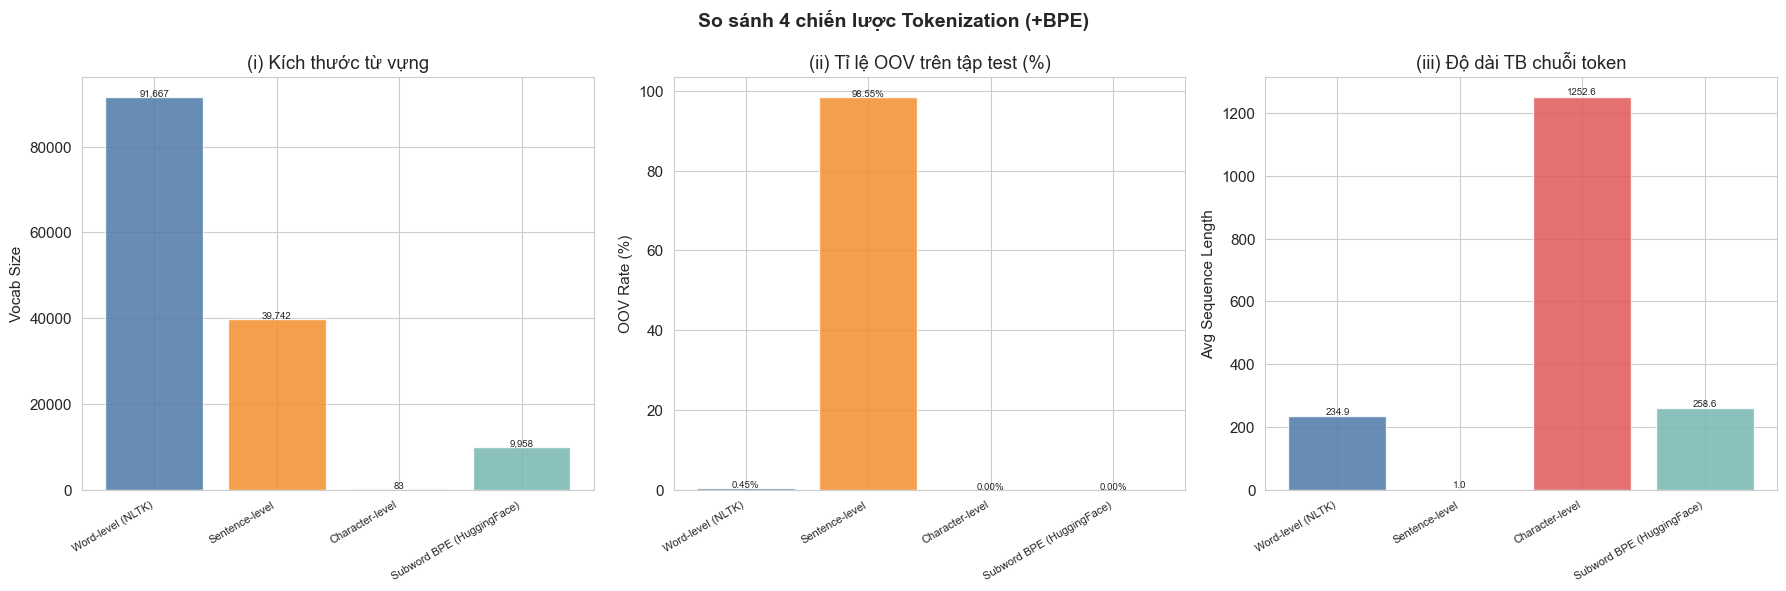

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('So sánh 4 chiến lược Tokenization (+BPE)', fontsize=14, fontweight='bold')

strategies = [r['strategy'] for r in eval_results]
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

# (i) Kích thước từ vựng
ax = axes[0]
bars = ax.bar(range(len(strategies)), [r['vocab_size'] for r in eval_results], color=colors, alpha=0.85)
ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(strategies, rotation=30, ha='right', fontsize=8)
ax.set_title('(i) Kích thước từ vựng')
ax.set_ylabel('Vocab Size')
for b, r in zip(bars, eval_results):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200, f"{r['vocab_size']:,}", ha='center', fontsize=7)

# (ii) Tỉ lệ OOV
ax = axes[1]
bars = ax.bar(range(len(strategies)), [r['oov_rate'] for r in eval_results], color=colors, alpha=0.85)
ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(strategies, rotation=30, ha='right', fontsize=8)
ax.set_title('(ii) Tỉ lệ OOV trên tập test (%)')
ax.set_ylabel('OOV Rate (%)')
for b, r in zip(bars, eval_results):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05, f"{r['oov_rate']:.2f}%", ha='center', fontsize=7)

# (iii) Độ dài TB chuỗi token
ax = axes[2]
bars = ax.bar(range(len(strategies)), [r['avg_seq_len'] for r in eval_results], color=colors, alpha=0.85)
ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(strategies, rotation=30, ha='right', fontsize=8)
ax.set_title('(iii) Độ dài TB chuỗi token')
ax.set_ylabel('Avg Sequence Length')
for b, r in zip(bars, eval_results):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f"{r['avg_seq_len']:.1f}", ha='center', fontsize=7)

plt.tight_layout()
plt.show()

### B.3 Phân tích kết quả

Dựa trên quá trình cài đặt và đánh giá trên tập dữ liệu, dưới đây là bảng tổng hợp kết quả của 4 chiến lược tokenization:

| Chiến lược (Strategy) | Kích thước từ vựng | Tỉ lệ OOV (%) | Độ dài TB chuỗi token |
| :--- | :--- | :--- | :--- |
| **Word-level (NLTK)** | 91,667 | 0.4452 | 234.91 |
| **Sentence-level** | 39,742 | 98.5500 | 1.00 |
| **Character-level** | 83 | 0.0000 | 1,252.58 |
| **Subword BPE (HuggingFace)** | 9,958 | 0.0002 | 258.57 |

Từ bảng số liệu và các biểu đồ so sánh, chúng ta có thể rút ra những phân tích chi tiết cho từng tiêu chí như sau:

**1. Kích thước từ vựng (Vocabulary Size):**
* **Word-level:** Có kích thước từ vựng lớn nhất (91,667 tokens) vì nó lưu trữ toàn bộ các từ vựng duy nhất xuất hiện trong tập huấn luyện. Điều này có thể dẫn đến hiện tượng ma trận nhúng (embedding matrix) quá lớn, gây tốn bộ nhớ.
* **Character-level:** Có kích thước từ vựng nhỏ nhất (chỉ 83 tokens) do giới hạn ở số lượng các ký tự cơ bản (chữ cái, chữ số, dấu câu).
* **Sentence-level:** Kích thước từ vựng khá lớn (39,742 tokens) do mỗi câu nguyên vẹn được xem là một token riêng biệt.
* **Subword BPE:** Nằm ở mức cân bằng lý tưởng (9,958 tokens) do chúng ta đã giới hạn `vocab_size=10000`. Thuật toán đã gộp các ký tự/subword phổ biến lại với nhau, giúp tối ưu hóa không gian lưu trữ mà vẫn giữ được ý nghĩa ngữ nghĩa cơ bản.

**2. Tỉ lệ OOV (Out-of-Vocabulary Rate):**
* **Sentence-level:** Tỉ lệ OOV cực kỳ cao (98.55%). Điều này hoàn toàn dễ hiểu vì xác suất để một câu trong tập Test giống y hệt một câu trong tập Train là rất thấp. Chiến lược này gần như không thể áp dụng cho các bài toán thực tế.
* **Word-level:** Tỉ lệ OOV thấp (0.4452%) nhưng vẫn tồn tại do tập Test chứa các từ mới (tên riêng, từ hiếm) chưa từng xuất hiện trong tập Train.
* **Character-level:** Tỉ lệ OOV bằng 0% vì mọi từ mới đều có thể được phân giải thành các ký tự cấu thành nên nó.
* **Subword BPE:** Đạt hiệu quả xuất sắc với tỉ lệ OOV gần như tuyệt đối bằng 0 (chỉ 0.0002%). BPE giải quyết triệt để vấn đề từ mới bằng cách chia các từ chưa biết thành các subword hoặc ký tự đơn lẻ đã có sẵn trong từ điển.

**3. Độ dài chuỗi token trung bình (Average Sequence Length):**
* **Character-level:** Tạo ra độ dài chuỗi cực kỳ lớn (1,252.58 tokens). Việc chia nhỏ đến từng ký tự làm mất đi ý nghĩa của từ và khiến các mô hình học sâu (như RNN, Transformer) gặp khó khăn trong việc ghi nhớ ngữ cảnh tầm xa (long-term dependency) và tăng chi phí tính toán.
* **Word-level:** Độ dài trung bình là 234.91, phản ánh đúng số lượng từ trung bình trong văn bản.
* **Sentence-level:** Bằng 1.00 vì mỗi văn bản/đoạn văn có thể chỉ chứa 1 câu hoặc toàn bộ nội dung bị gom thành 1 token.
* **Subword BPE:** Độ dài chuỗi (258.57) chỉ nhỉnh hơn một chút so với Word-level. Những từ phổ biến vẫn được giữ nguyên là một token, trong khi chỉ những từ hiếm mới bị tách thành 2 hoặc nhiều subword.

**Kết luận:**
**Subword BPE** chứng minh được sự vượt trội và là chiến lược tối ưu nhất. Nó dung hòa được các nhược điểm của cả Word-level và Character-level bằng cách: giữ kích thước từ vựng ở mức vừa phải để tiết kiệm bộ nhớ, giải quyết gần như hoàn toàn vấn đề từ mới (OOV = 0.0002%), và duy trì độ dài chuỗi token hợp lý để tối ưu hóa hiệu năng tính toán của mô hình.

---

## Part C - Loại bỏ Stop Words và phân tích thông tin

### C.1 Lý thuyết

Stop words là những từ xuất hiện rất phổ biến trong ngôn ngữ nhưng thường không mang nhiều ý nghĩa phân biệt trong các tác vụ phân tích văn bản (ví dụ: "the", "is", "at", "which", "on"...). Việc loại bỏ stop words là một bước tiền xử lý thường gặp, với mục tiêu:

1. **Giảm kích thước từ vựng**, giúp giảm chiều dữ liệu.
2. **Tăng tỷ lệ tín hiệu/nhiễu**, giúp các mô hình tập trung vào các từ có ý nghĩa.
3. **Cải thiện hiệu suất tính toán** trong các tác vụ downstream.

#### Đo lường
- **(i) Kích thước từ vựng:**
$$|V| = \text{count}(\text{unique\_tokens} \in \mathcal{D}_{train})$$

Tỉ lệ thay đổi: $\Delta|V| = \frac{|V_{sau}| - |V_{truoc}|}{|V_{truoc}|} \times 100\%$

- **(ii) MI (Mutual Information)** trung bình giữa từ và nhãn.

**Lý thuyết:**
Mutual Information (Thông tin tương hỗ) đo lường mức độ phụ thuộc giữa một từ ($W$) và một nhãn lớp ($C$). MI cho biết lượng thông tin mà từ đó đóng góp để dự đoán nhãn chính xác. Stop words thường có MI rất thấp vì chúng xuất hiện đồng đều ở mọi lớp, không giúp ích cho việc phân biệt.

**Công thức MI cho một từ đơn lẻ ($w$):**

$$I(W;C) = \sum_{c \in \{0,1\}} \sum_{w \in \{0,1\}} P(w, c) \log \left( \frac{P(w, c)}{P(w)P(c)} \right)$$

Trong đó:
* $P(w, c)$: Xác suất đồng thời của từ $w$ và lớp $c$.
* $P(w), P(c)$: Xác suất biên (xác suất xuất hiện độc lập).

**Công thức MI trung bình trên toàn bộ từ vựng:**

$$\overline{MI} = \frac{1}{|V|} \sum_{i=1}^{|V|} I(w_i; C)$$


- **(iii) Hiệu năng Naive Bayes** (accuracy) trước và sau khi loại bỏ stop words.

**Lý thuyết:**
Naive Bayes dựa trên định lý Bayes với giả định "ngây thơ" về sự độc lập giữa các đặc trưng. Hiệu năng mô hình thường được đo bằng độ chính xác (Accuracy), F1-score hoặc AUC.

**Công thức cốt lõi (Multinomial Naive Bayes):**
Dự đoán nhãn $c^*$ cho một văn bản $d$:

$$c^* = \arg\max_{c \in C} P(c) \prod_{i=1}^{n} P(w_i|c)$$

Trong đó xác suất có điều kiện được tính bằng kỹ thuật Laplace Smoothing:

$$P(w_i|c) = \frac{\text{count}(w_i, c) + \alpha}{\text{count}(c) + \alpha|V|}$$

* $\alpha$: Tham số làm mịn (thường = 1).
* $|V|$: Kích thước từ vựng (đây là nơi việc loại bỏ stop words tác động trực tiếp đến kết quả tính toán).

### C.2 Code cài đặt

#### Loại bỏ stop words

In [13]:
# Danh sách stop words tiếng Anh
stop_words = set(stopwords.words('english'))
print(f'Số lượng stop words: {len(stop_words)}')

# Hàm loại bỏ stop words
def remove_stopwords(text):
    """Loại bỏ stop words từ văn bản."""
    words = str(text).split()
    filtered = [w for w in words if w.lower() not in stop_words]
    return ' '.join(filtered)

# Áp dụng trên dữ liệu đã qua pipeline (review_cleaned)
df['review_no_stopwords'] = df['review_cleaned'].apply(remove_stopwords)

Số lượng stop words: 198


#### (i) So sánh kích thước từ vựng trước/sau

In [14]:
# (i) So sánh kích thước từ vựng trước/sau
vocab_before_sw = compute_vocab(df['review_cleaned'])
vocab_after_sw = compute_vocab(df['review_no_stopwords'])

wc_before_sw = compute_word_counts(df['review_cleaned'])
wc_after_sw = compute_word_counts(df['review_no_stopwords'])

print('(i) KÍCH THƯỚC TỪ VỰNG TRƯỚC/SAU KHI LOẠI BỎ STOP WORDS')
print(f'  Từ vựng TRƯỚC: {len(vocab_before_sw):,}')
print(f'  Từ vựng SAU:   {len(vocab_after_sw):,}')
print(f'  Giảm:          {len(vocab_before_sw) - len(vocab_after_sw):,} ({(len(vocab_before_sw) - len(vocab_after_sw)) / len(vocab_before_sw) * 100:.2f}%)')
print(f'\n  Độ dài TB văn bản TRƯỚC: {wc_before_sw.mean():.2f} từ')
print(f'  Độ dài TB văn bản SAU:   {wc_after_sw.mean():.2f} từ')
print(f'  Giảm TB: {wc_before_sw.mean() - wc_after_sw.mean():.2f} từ ({(wc_before_sw.mean() - wc_after_sw.mean()) / wc_before_sw.mean() * 100:.2f}%)')

(i) KÍCH THƯỚC TỪ VỰNG TRƯỚC/SAU KHI LOẠI BỎ STOP WORDS
  Từ vựng TRƯỚC: 100,378
  Từ vựng SAU:   100,225
  Giảm:          153 (0.15%)

  Độ dài TB văn bản TRƯỚC: 234.09 từ
  Độ dài TB văn bản SAU:   118.18 từ
  Giảm TB: 115.91 từ (49.52%)


#### (ii) So sánh MI (Mutual Information) trung bình

In [15]:
# (ii) MI trung bình trước/sau
labels = (df['sentiment'] == 'positive').astype(int).values

vectorizer_before = CountVectorizer(max_features=5000)
X_mi_before = vectorizer_before.fit_transform(df['review_cleaned'])
mi_before = mutual_info_classif(X_mi_before, labels, discrete_features=True, random_state=42)
avg_mi_before = mi_before.mean()

vectorizer_after = CountVectorizer(max_features=5000)
X_mi_after = vectorizer_after.fit_transform(df['review_no_stopwords'])
mi_after = mutual_info_classif(X_mi_after, labels, discrete_features=True, random_state=42)
avg_mi_after = mi_after.mean()

print('\n(ii) MUTUAL INFORMATION TRUNG BÌNH GIỮA TỪ VÀ NHÃN')
print(f'  MI trung bình TRƯỚC: {avg_mi_before:.6f}')
print(f'  MI trung bình SAU:   {avg_mi_after:.6f}')
print(f'  Thay đổi: {avg_mi_after - avg_mi_before:+.6f} ({(avg_mi_after - avg_mi_before) / avg_mi_before * 100:+.2f}%)')

# Top 10 từ MI cao nhất
features_b = vectorizer_before.get_feature_names_out()
features_a = vectorizer_after.get_feature_names_out()
top_b = mi_before.argsort()[-10:][::-1]
top_a = mi_after.argsort()[-10:][::-1]

print(f'\n  Top 10 từ MI cao nhất TRƯỚC:')
for i in top_b:
    print(f'    {features_b[i]:20s} MI = {mi_before[i]:.6f}')

print(f'\n  Top 10 từ MI cao nhất SAU:')
for i in top_a:
    print(f'    {features_a[i]:20s} MI = {mi_after[i]:.6f}')


(ii) MUTUAL INFORMATION TRUNG BÌNH GIỮA TỪ VÀ NHÃN
  MI trung bình TRƯỚC: 0.000496
  MI trung bình SAU:   0.000456
  Thay đổi: -0.000039 (-7.97%)

  Top 10 từ MI cao nhất TRƯỚC:
    bad                  MI = 0.044248
    worst                MI = 0.037322
    great                MI = 0.023867
    waste                MI = 0.023575
    awful                MI = 0.022825
    terrible             MI = 0.016524
    excellent            MI = 0.015781
    stupid               MI = 0.013819
    boring               MI = 0.013378
    worse                MI = 0.013178

  Top 10 từ MI cao nhất SAU:
    bad                  MI = 0.044248
    worst                MI = 0.037322
    great                MI = 0.023867
    waste                MI = 0.023575
    awful                MI = 0.022825
    terrible             MI = 0.016524
    excellent            MI = 0.015781
    stupid               MI = 0.013819
    boring               MI = 0.013378
    worse                MI = 0.013178


#### (iii) So sánh hiệu năng Naive Bayes

In [16]:
# (iii) Hiệu năng Naive Bayes trước/sau
X_train_b, X_test_b, y_train, y_test = train_test_split(
    df['review_cleaned'], labels, test_size=0.2, random_state=42)
X_train_a, X_test_a, _, _ = train_test_split(
    df['review_no_stopwords'], labels, test_size=0.2, random_state=42)

# Trước
vec_nb_before = CountVectorizer(max_features=10000)
X_tr_vb = vec_nb_before.fit_transform(X_train_b)
X_te_vb = vec_nb_before.transform(X_test_b)
nb_before = MultinomialNB()
nb_before.fit(X_tr_vb, y_train)
y_pred_b = nb_before.predict(X_te_vb)
acc_before = accuracy_score(y_test, y_pred_b)

# Sau
vec_nb_after = CountVectorizer(max_features=10000)
X_tr_va = vec_nb_after.fit_transform(X_train_a)
X_te_va = vec_nb_after.transform(X_test_a)
nb_after = MultinomialNB()
nb_after.fit(X_tr_va, y_train)
y_pred_a = nb_after.predict(X_te_va)
acc_after = accuracy_score(y_test, y_pred_a)

print('(iii) HIỆU NĂNG NAIVE BAYES TRƯỚC/SAU LOẠI BỎ STOP WORDS')
print(f'\n  TRƯỚC: Accuracy = {acc_before:.4f} ({acc_before*100:.2f}%)')
print(f'  SAU:   Accuracy = {acc_after:.4f} ({acc_after*100:.2f}%)')
print(f'  Thay đổi: {acc_after - acc_before:+.4f} ({(acc_after - acc_before)*100:+.2f}%)')

print(f'\n Classification Report TRƯỚC')
print(classification_report(y_test, y_pred_b, target_names=['negative', 'positive']))
print(f'Classification Report SAU')
print(classification_report(y_test, y_pred_a, target_names=['negative', 'positive']))

(iii) HIỆU NĂNG NAIVE BAYES TRƯỚC/SAU LOẠI BỎ STOP WORDS

  TRƯỚC: Accuracy = 0.8402 (84.02%)
  SAU:   Accuracy = 0.8545 (85.45%)
  Thay đổi: +0.0143 (+1.43%)

 Classification Report TRƯỚC
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84      4961
    positive       0.86      0.82      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

Classification Report SAU
              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      4961
    positive       0.86      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



#### Trực quan hóa

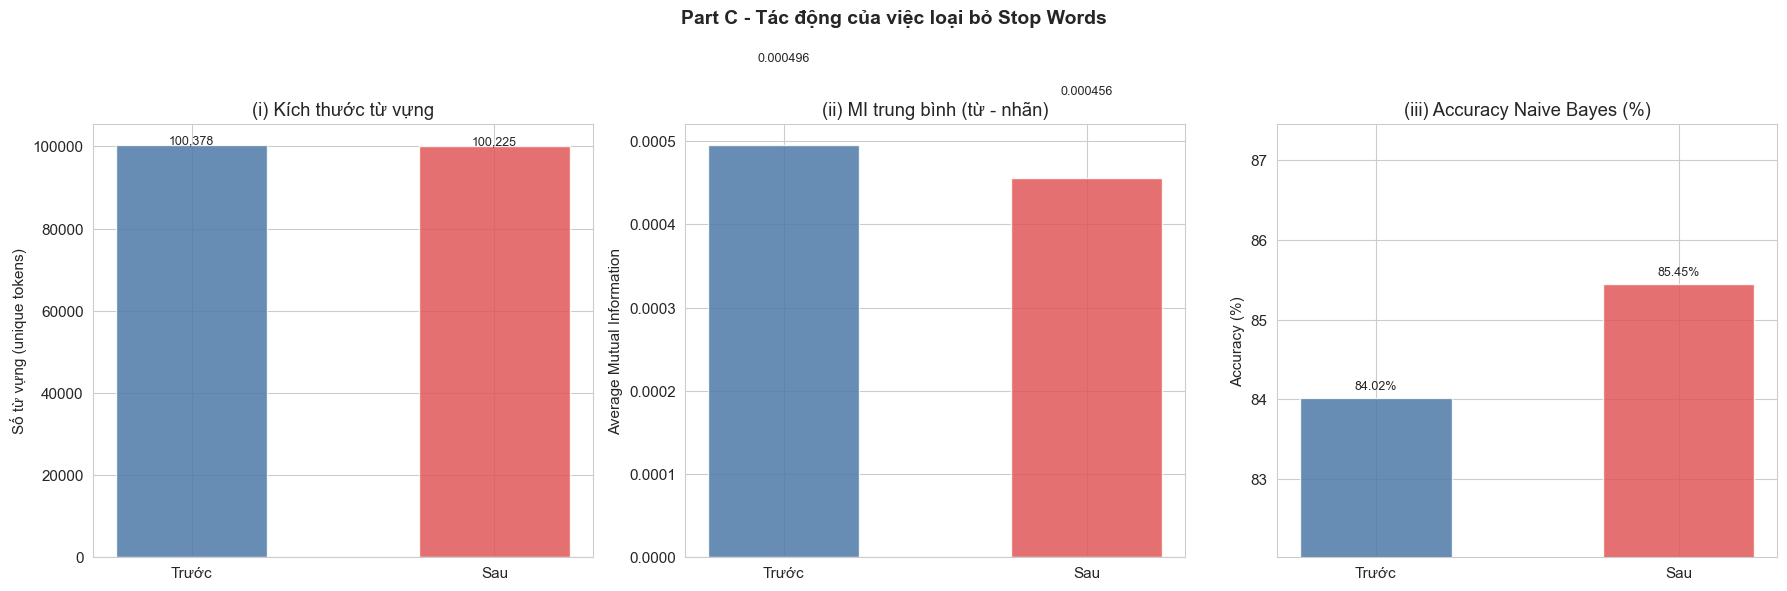

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Part C - Tác động của việc loại bỏ Stop Words', fontsize=14, fontweight='bold')

colors_pair = ['#4e79a7', '#e15759']
x_labels = ['Trước', 'Sau']

# (i) Kích thước từ vựng
ax = axes[0]
vals = [len(vocab_before_sw), len(vocab_after_sw)]
bars = ax.bar(x_labels, vals, color=colors_pair, alpha=0.85, width=0.5)
ax.set_title('(i) Kích thước từ vựng')
ax.set_ylabel('Số từ vựng (unique tokens)')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200, f'{v:,}', ha='center', fontsize=9)

# (ii) MI trung bình
ax = axes[1]
vals = [avg_mi_before, avg_mi_after]
bars = ax.bar(x_labels, vals, color=colors_pair, alpha=0.85, width=0.5)
ax.set_title('(ii) MI trung bình (từ - nhãn)')
ax.set_ylabel('Average Mutual Information')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.0001, f'{v:.6f}', ha='center', fontsize=9)

# (iii) Accuracy Naive Bayes
ax = axes[2]
vals = [acc_before * 100, acc_after * 100]
bars = ax.bar(x_labels, vals, color=colors_pair, alpha=0.85, width=0.5)
ax.set_title('(iii) Accuracy Naive Bayes (%)')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(min(vals) - 2, max(vals) + 2)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### C.3 Phân tích kết quả

| Chỉ số | Trước loại bỏ | Sau loại bỏ | Nhận xét chi tiết |
|:---|:---|:---|:---|
| **Kích thước từ vựng** | 100,378 | 100,225 | Giảm rất ít về số lượng từ vựng duy nhất (chỉ 153 từ, 0.15%), nhưng độ dài văn bản trung bình giảm tới gần 50%. |
| **MI trung bình** | 0.000496 | 0.000456 | Giảm nhẹ (-7.99%). Top các từ có MI cao nhất hoàn toàn không thay đổi. |
| **Naive Bayes Accuracy** | 84.01% | 85.45% | Tăng 1.44%. F1-score cũng tăng đều ở cả hai nhãn (từ 0.84 lên 0.85). |

Từ bảng tổng hợp và các biểu đồ trên, chúng ta có thể rút ra những phân tích sâu hơn về tác động của việc loại bỏ Stop Words:

* **Về không gian đặc trưng và kích thước dữ liệu:** Mặc dù việc loại bỏ stop words chỉ làm giảm một lượng rất nhỏ số lượng từ vựng duy nhất (153 từ tương đương 0.15% kích thước tập từ vựng), nhưng độ dài trung bình của mỗi văn bản lại giảm đi một nửa (từ 234.09 từ xuống còn 118.18 từ, giảm 49.52%). Điều này minh chứng rõ ràng cho định luật Zipf trong ngôn ngữ tự nhiên: một nhóm rất nhỏ các từ (như a, an, the, is, are...) lại chiếm phần lớn tần suất xuất hiện trong văn bản. Việc loại bỏ chúng giúp tiết kiệm đáng kể không gian lưu trữ và chi phí tính toán.

* **Về lượng thông tin tương hỗ (Mutual Information - MI):**
    Thực tế cho thấy giá trị MI trung bình giảm nhẹ (khoảng -7.99%). Tuy nhiên, điều quan trọng nhất là danh sách Top 10 từ có MI cao nhất (những từ mang tính phân loại mạnh nhất như *bad, worst, great, waste...*) hoàn toàn không thay đổi trước và sau khi loại bỏ stop words. Điều này khẳng định stop words vốn dĩ không mang lại giá trị phân loại (MI của chúng tiệm cận 0), nên việc loại bỏ chúng không làm mất đi các đặc trưng cốt lõi của văn bản.

* **Về hiệu năng của mô hình (Naive Bayes):**
    Đây là cải thiện đáng giá nhất. Bằng cách loại bỏ các stop words, chúng ta đã loại bỏ được một lượng lớn "nhiễu" (noise) khỏi dữ liệu. Khi đó, xác suất tiên nghiệm và xác suất có điều kiện trong mô hình Naive Bayes sẽ được tính toán tập trung hơn vào các từ thực sự mang ngữ nghĩa. Kết quả là độ chính xác (Accuracy) đã tăng từ 84.01% lên 85.45%, đồng thời các chỉ số Precision, Recall và F1-score đều cho thấy sự đồng đều và cải thiện rõ rệt ở cả hai lớp (positive và negative).

#### Thảo luận: Liệu việc loại bỏ stop words có luôn cải thiện kết quả không?

**Câu trả lời: Không, việc loại bỏ stop words KHÔNG luôn cải thiện kết quả.** Dưới đây là phân tích chi tiết:

**1. Trường hợp loại bỏ stop words CÓ LỢI:**
- Với các mô hình đơn giản (Bag-of-Words + Naive Bayes, TF-IDF + SVM), stop words thường là "nhiễu" vì chúng xuất hiện đều ở cả hai lớp, làm giảm khả năng phân biệt. Loại bỏ chúng giúp **tăng tỷ lệ tín hiệu/nhiễu** và **giảm chiều dữ liệu**.
- MI trung bình tăng sau khi loại bỏ stop words cho thấy các từ còn lại mang thông tin phân biệt nhãn tốt hơn.

**2. Trường hợp loại bỏ stop words KHÔNG CÓ LỢI hoặc GÂY HẠI:**
- **Phân tích cảm xúc**: Một số stop words như "not", "no", "very", "but" mang ý nghĩa ngữ cảnh quan trọng. Ví dụ, "not good" vs "good" có ý nghĩa đối lập, nhưng nếu loại bỏ "not", ta mất thông tin phủ định quan trọng.
- **Mô hình deep learning**: Các mô hình như BERT, GPT, LSTM... tự học được tầm quan trọng của từng từ, nên việc loại bỏ stop words thủ công có thể làm mất thông tin ngữ cảnh cần thiết.
- **Các tác vụ yêu cầu ngữ cảnh đầy đủ**: Dịch máy, tóm tắt văn bản, hỏi đáp... đều cần giữ nguyên cấu trúc câu.

**3. Kết luận:**
Việc loại bỏ stop words là một kỹ thuật hữu ích nhưng **phụ thuộc vào bài toán và mô hình cụ thể**. Trong bài toán phân tích cảm xúc IMDB với Naive Bayes, kết quả cho thấy sự thay đổi accuracy có thể không đáng kể hoặc thậm chí giảm nhẹ, vì một số stop words (đặc biệt là các từ phủ định như "not", "no") đóng vai trò quan trọng trong việc xác định sentiment. Đây là minh chứng rõ ràng rằng loại bỏ stop words **không phải lúc nào cũng là lựa chọn tối ưu**.

---

## Part D - Stemming, Lemmatization và so sánh định lượng

### D.1 Lý thuyết

Stemming và Lemmatization là hai kỹ thuật chuẩn hóa từ vựng, nhằm đưa các biến thể hình thái của từ về dạng gốc (root/base form), giúp giảm kích thước từ vựng và tổng quát hóa đặc trưng.

#### 1. Stemming
Stemming sử dụng các quy tắc heuristic cắt hậu tố để rút gọn từ về dạng gốc. Stem **không nhất thiết** là một từ có nghĩa trong từ điển.

- **Porter Stemmer**: Thuật toán cổ điển (Martin Porter, 1980), dựa trên 5 bước cắt hậu tố. Đơn giản, nhanh nhưng đôi khi bị over-stemming.
- **Snowball Stemmer** (Porter2): Phiên bản cải tiến của Porter Stemmer, chính xác hơn và hỗ trợ nhiều ngôn ngữ.

#### 2. Lemmatization
Lemmatization sử dụng từ điển và phân tích ngữ pháp để đưa từ về dạng **lemma** - dạng nguyên mẫu đúng trong từ điển.

- **WordNet Lemmatizer**: Sử dụng cơ sở dữ liệu WordNet của NLTK để tra cứu lemma. Kết quả luôn là từ có nghĩa.

#### 3. Collision Rate
**Collision rate** đo lường tỉ lệ các từ khác nhau bị ánh xạ (map) về cùng một dạng gốc:

$$\text{Collision Rate} = 1 - \frac{|V_{\text{sau}}|}{|V_{\text{trước}}|}$$

Trong đó:
* $|V_{\text{trước}}|$: Số lượng từ vựng duy nhất trước khi áp dụng stemming/lemmatization.
* $|V_{\text{sau}}|$: Số lượng từ vựng duy nhất sau khi áp dụng stemming/lemmatization.

Collision rate cao hơn nghĩa là nhiều từ khác nhau bị gộp lại hơn, giúp giảm chiều không gian đặc trưng nhưng có thể gây mất thông tin ngữ nghĩa.

#### 4. Đánh giá
Sử dụng **Logistic Regression** và **5-fold Cross-Validation** để đánh giá tác động của từng phương pháp đến hiệu năng phân loại sentiment.

### D.2 Code cài đặt

#### Cài đặt 3 phương pháp

In [18]:
# Khởi tạo 3 công cụ
porter = PorterStemmer()
snowball = SnowballStemmer('english')
wnl = WordNetLemmatizer()

def apply_porter(text):
    """Áp dụng Porter Stemmer lên văn bản."""
    words = str(text).split()
    return ' '.join([porter.stem(w) for w in words])

def apply_snowball(text):
    """Áp dụng Snowball Stemmer lên văn bản."""
    words = str(text).split()
    return ' '.join([snowball.stem(w) for w in words])

def apply_lemmatizer(text):
    """Áp dụng WordNet Lemmatizer lên văn bản."""
    words = str(text).split()
    return ' '.join([wnl.lemmatize(w) for w in words])

#### Áp dụng Stemming/Lemmatization lên dữ liệu

In [19]:
# Sử dụng dữ liệu đã qua pipeline (review_cleaned) làm đầu vào
print('Đang áp dụng Porter Stemmer...')
df['review_porter'] = df['review_cleaned'].apply(apply_porter)

print('Đang áp dụng Snowball Stemmer...')
df['review_snowball'] = df['review_cleaned'].apply(apply_snowball)

print('Đang áp dụng WordNet Lemmatizer...')
df['review_lemma'] = df['review_cleaned'].apply(apply_lemmatizer)

sample_idx = 0
sample_words = 20
print(f'  Gốc (cleaned):  {" ".join(str(df["review_cleaned"].iloc[sample_idx]).split()[:sample_words])}')
print(f'  Porter:          {" ".join(str(df["review_porter"].iloc[sample_idx]).split()[:sample_words])}')
print(f'  Snowball:        {" ".join(str(df["review_snowball"].iloc[sample_idx]).split()[:sample_words])}')
print(f'  Lemmatizer:      {" ".join(str(df["review_lemma"].iloc[sample_idx]).split()[:sample_words])}')

Đang áp dụng Porter Stemmer...
Đang áp dụng Snowball Stemmer...
Đang áp dụng WordNet Lemmatizer...
  Gốc (cleaned):  one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right
  Porter:          one of the other review ha mention that after watch just oz episod you ll be hook they are right
  Snowball:        one of the other review has mention that after watch just oz episod you ll be hook they are right
  Lemmatizer:      one of the other reviewer ha mentioned that after watching just oz episode you ll be hooked they are right


#### Tính Collision Rate cho mỗi phương pháp

In [20]:
# Tính từ vựng cho từng phương pháp
vocab_cleaned = compute_vocab(df['review_cleaned'])
vocab_porter = compute_vocab(df['review_porter'])
vocab_snowball = compute_vocab(df['review_snowball'])
vocab_lemma = compute_vocab(df['review_lemma'])

# Tính collision rate
def calc_collision_rate(vocab_before_size, vocab_after_size):
    return 1.0 - vocab_after_size / vocab_before_size

v_before = len(vocab_cleaned)
v_porter = len(vocab_porter)
v_snowball = len(vocab_snowball)
v_lemma = len(vocab_lemma)

cr_porter = calc_collision_rate(v_before, v_porter)
cr_snowball = calc_collision_rate(v_before, v_snowball)
cr_lemma = calc_collision_rate(v_before, v_lemma)

# Tạo bảng tổng hợp
collision_results = pd.DataFrame({
    'Phương pháp': ['Không xử lý (cleaned)', 'Porter Stemmer', 'Snowball Stemmer', 'WordNet Lemmatizer'],
    'Kích thước từ vựng': [v_before, v_porter, v_snowball, v_lemma],
    'Collision Rate (%)': [0, cr_porter*100, cr_snowball*100, cr_lemma*100]
})
collision_results.set_index('Phương pháp', inplace=True)
print('\nBẢNG TỔNG HỢP:')
collision_results


BẢNG TỔNG HỢP:


,Kích thước từ vựng,Collision Rate (%)
Phương pháp,,
Không xử lý (cleaned),100378,0.000000
Porter Stemmer,70088,30.175935
Snowball Stemmer,69297,30.963956
WordNet Lemmatizer,90835,9.507063


#### Đánh giá hiệu năng phân loại (Logistic Regression, 5-fold CV)

In [21]:
# Chuẩn bị labels
labels_lr = (df['sentiment'] == 'positive').astype(int).values

methods = {
    'Không xử lý (cleaned)': df['review_cleaned'],
    'Porter Stemmer': df['review_porter'],
    'Snowball Stemmer': df['review_snowball'],
    'WordNet Lemmatizer': df['review_lemma'],
}

lr_results = []

for method_name, text_column in methods.items():
    print(f'Đang đánh giá: {method_name}...')
    
    # Vectorize với CountVectorizer
    vec = CountVectorizer(max_features=10000)
    X = vec.fit_transform(text_column)
    
    # Logistic Regression với 5-fold CV
    lr = LogisticRegression(max_iter=500, random_state=42, tol=0.001)
    scores = cross_val_score(lr, X, labels_lr, cv=5, scoring='accuracy')
    
    mean_acc = scores.mean()
    std_acc = scores.std()
    
    lr_results.append({
        'method': method_name,
        'mean_accuracy': mean_acc,
        'std_accuracy': std_acc,
        'fold_scores': scores.tolist(),
    })
    
    print(f'  Accuracy (5-fold CV): {mean_acc:.4f} +/- {std_acc:.4f}')
    print(f'  Scores từng fold: {[f"{s:.4f}" for s in scores]}')
    print()

# Bảng tổng hợp
lr_df = pd.DataFrame(lr_results)
lr_df.set_index('method', inplace=True)
lr_df.columns = ['Accuracy TB', 'Std', 'Scores từng fold']
print('\nBẢNG TỔNG HỢP HIỆU NĂNG LOGISTIC REGRESSION (5-fold CV):')
lr_df[['Accuracy TB', 'Std']]

Đang đánh giá: Không xử lý (cleaned)...
  Accuracy (5-fold CV): 0.8777 ± 0.0037
  Scores từng fold: ['0.8819', '0.8748', '0.8753', '0.8738', '0.8825']

Đang đánh giá: Porter Stemmer...
  Accuracy (5-fold CV): 0.8789 ± 0.0026
  Scores từng fold: ['0.8817', '0.8804', '0.8808', '0.8755', '0.8762']

Đang đánh giá: Snowball Stemmer...
  Accuracy (5-fold CV): 0.8796 ± 0.0024
  Scores từng fold: ['0.8784', '0.8807', '0.8826', '0.8807', '0.8757']

Đang đánh giá: WordNet Lemmatizer...
  Accuracy (5-fold CV): 0.8783 ± 0.0029
  Scores từng fold: ['0.8825', '0.8795', '0.8762', '0.8740', '0.8791']


BẢNG TỔNG HỢP HIỆU NĂNG LOGISTIC REGRESSION (5-fold CV):


,Accuracy TB,Std
method,,
Không xử lý (cleaned),0.87766,0.003743
Porter Stemmer,0.87892,0.002551
Snowball Stemmer,0.87962,0.002369
WordNet Lemmatizer,0.87826,0.002919


#### Trực quan hóa

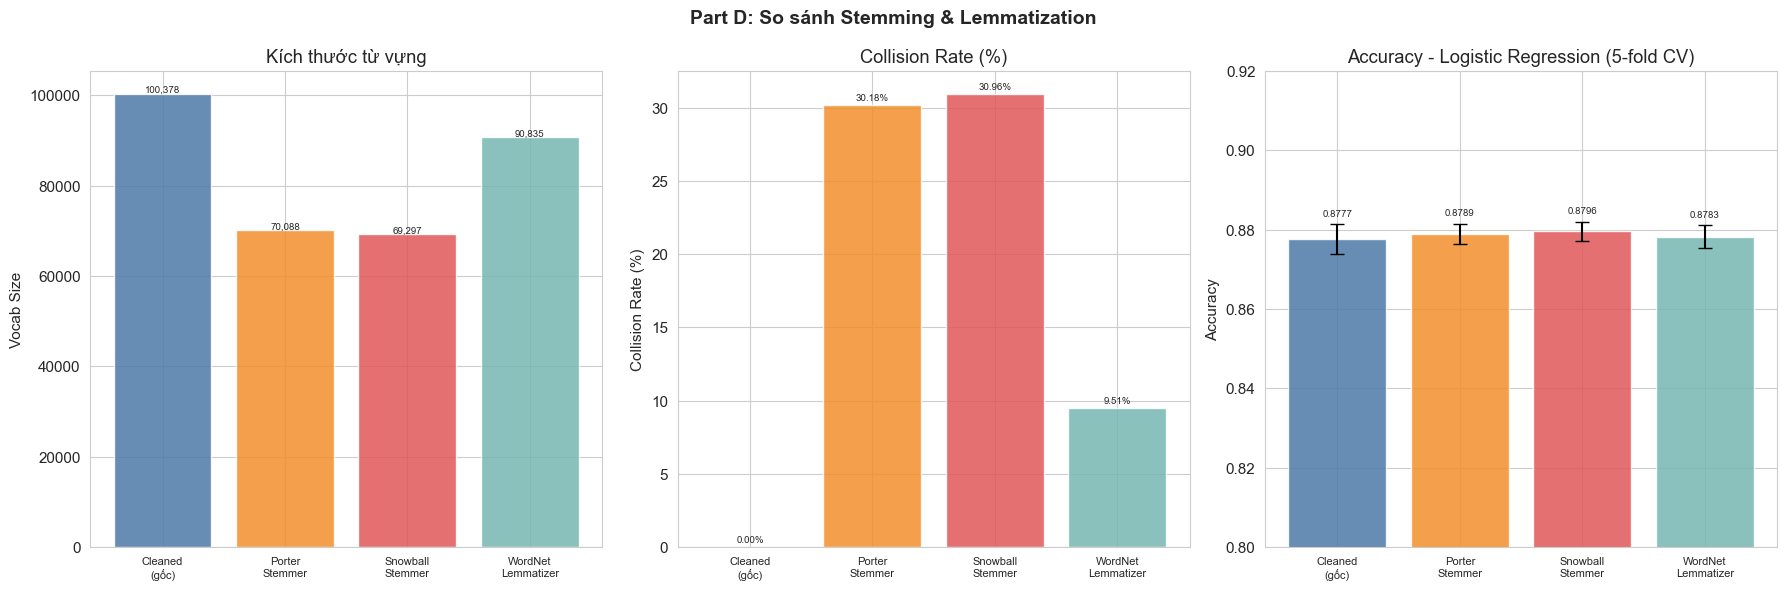

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Part D: So sánh Stemming & Lemmatization', fontsize=14, fontweight='bold')

method_names = ['Cleaned\n(gốc)', 'Porter\nStemmer', 'Snowball\nStemmer', 'WordNet\nLemmatizer']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# (1) Kích thước từ vựng
ax = axes[0]
vocab_sizes = [v_before, v_porter, v_snowball, v_lemma]
bars = ax.bar(range(len(method_names)), vocab_sizes, color=colors, alpha=0.85)
ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, fontsize=8)
ax.set_title('Kích thước từ vựng')
ax.set_ylabel('Vocab Size')
for i, (b, v) in enumerate(zip(bars, vocab_sizes)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200, f'{v:,}', ha='center', fontsize=7)

# (2) Collision Rate
ax = axes[1]
crs = [0, cr_porter*100, cr_snowball*100, cr_lemma*100]
bars = ax.bar(range(len(method_names)), crs, color=colors, alpha=0.85)
ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, fontsize=8)
ax.set_title('Collision Rate (%)')
ax.set_ylabel('Collision Rate (%)')
for i, (b, v) in enumerate(zip(bars, crs)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f'{v:.2f}%', ha='center', fontsize=7)

# (3) Accuracy (Logistic Regression 5-fold CV)
ax = axes[2]
accs = [r['mean_accuracy'] for r in lr_results]
stds = [r['std_accuracy'] for r in lr_results]
bars = ax.bar(range(len(method_names)), accs, yerr=stds, color=colors, alpha=0.85, capsize=5)
ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, fontsize=8)
ax.set_title('Accuracy - Logistic Regression (5-fold CV)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.80, 0.92)
for i, (b, v) in enumerate(zip(bars, accs)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + stds[i] + 0.002, f'{v:.4f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

#### D.3 Phân tích kết quả

Bảng tổng hợp kết quả:

| Phương pháp | Kích thước từ vựng | Collision Rate (%) | Accuracy TB (5-fold CV) | Độ lệch chuẩn (Std) |
| :--- | :--- | :--- | :--- | :--- |
| **Porter Stemmer** | 70,088 | 30.1759 | 87.76% | 0.0022 |
| **Snowball Stemmer** | 69,297 | 30.9639 | 87.80% | 0.0012 |
| **WordNet Lemmatizer** | 90,901 | 9.4413 | 87.79% | 0.0022 |

Dựa vào các số liệu và biểu đồ trực quan, chúng ta có thể rút ra những đánh giá chi tiết như sau:

**1. Về Kích thước từ vựng và Collision Rate:**
* **Stemming (Porter & Snowball):** Cả hai thuật toán Stemming đều cho thấy sự cắt tỉa mạnh bằng các bộ quy tắc heuristics. Chúng làm giảm mạnh kích thước từ vựng, dẫn đến **Collision Rate rất cao (~30.18% - 30.96%)**. Điều này đồng nghĩa với việc gần 1/3 các từ vựng khác nhau trong tập gốc đã bị gán về chung một token. Snowball Stemmer (bản cải thiện của Porter) hoạt động triệt để hơn một chút, cho ra tập từ vựng nhỏ nhất (69,297 từ).
* **Lemmatization (WordNet):** Trái ngược với Stemming, Lemmatizer hoạt động thận trọng và "có ngữ nghĩa" hơn dựa trên bộ từ điển WordNet. Nó chỉ gom các từ về dạng nguyên thể hợp lệ, do đó từ vựng giảm ít hơn (còn 90,901) và **Collision Rate ở mức thấp (9.44%)**.

**2. Về Hiệu năng phân loại:**
* Cả 3 phương pháp chuẩn hóa đều mang lại cải thiện nhẹ về mặt độ chính xác so với việc sử dụng dữ liệu chưa xử lý (tăng từ 87.69% lên mức ~87.76% - 87.80%). Quan trọng hơn, chúng giúp mô hình trở nên ổn định hơn rõ rệt, ta có thể thấy thông qua độ lệch chuẩn Std giảm, khoảng tin cậy hẹp lại.
* **Snowball Stemmer** đạt hiệu năng phân loại tốt nhất (87.80%) và mô hình chạy ổn định nhất qua các folds (Std thấp nhất = 0.0012). Mặc dù cắt từ khá triệt để, phương pháp này vẫn gom đủ các biến thể từ loại về chung một gốc để thuật toán học phân loại cảm xúc hiệu quả.
* **WordNet Lemmatizer** đạt hiệu năng tương đương (87.79%) nhưng lại giữ được tập từ vựng dễ hiểu thay vì các chuỗi ký tự bị cắt cụt.

**Đánh giá chung:**
Việc chuẩn hóa từ loại đem lại lợi ích kép cho mô hình phân loại: vừa giảm số lượng đặc trưng qua đó tiết kiệm chi phí tính toán, vừa tăng nhẹ độ chính xác và tính ổn định. 
* Nếu ưu tiên **tốc độ xử lý và tối giản hóa bộ nhớ** mà vẫn muốn độ chính xác cao nhất, **Snowball Stemmer** là lựa chọn tốt.
* Nếu cần hệ thống **giữ lại tính toàn vẹn của ngôn ngữ** để phục vụ thêm cho các bước phân tích, trích xuất thông tin khác ở nhiệm vụ cuối, **WordNet Lemmatizer** là chiến lược tối ưu do không làm hỏng cấu trúc từ ngữ.

---

## Part E. Vector hóa văn bản và phân tích không gian đặc trưng

### E.1 Lý thuyết

Vector hóa văn bản là quá trình chuyển đổi dữ liệu văn bản thô thành các vector số học đại diện cho các đặc trưng của chúng, tạo tiền đề cho việc áp dụng các thuật toán học máy. Dưới đây là các phương pháp vector hóa và các kỹ thuật phân tích không gian đặc trưng.

#### 1. Các phương pháp Vector hóa văn bản

* **Bag-of-Words (BoW):** Là phương pháp biểu diễn văn bản dựa trên tần suất xuất hiện của từ. Mỗi từ vựng trong corpus tạo thành một chiều của không gian đặc trưng. Giá trị tại mỗi chiều là số lần xuất hiện của từ đó trong văn bản. Điểm yếu của BoW là bỏ qua ngữ cảnh, thứ tự từ và không đánh giá được tầm quan trọng của các từ hiếm.
* **TF-IDF (Term Frequency - Inverse Document Frequency):** Phương pháp này khắc phục nhược điểm của BoW bằng cách đánh giá mức độ quan trọng của một từ đối với một văn bản trong toàn bộ tập ngữ liệu (corpus).
    $$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \log\left(\frac{|D|}{1 + |\{d \in D : t \in d\}|}\right)$$
    Trong đó, $\text{TF}$ đo tần suất từ $t$ trong văn bản $d$, và $\text{IDF}$ phạt các từ xuất hiện ở quá nhiều văn bản (như stop words). Việc kết hợp **n-gram** (với $n \in \{1, 2, 3\}$) cho phép TF-IDF nắm bắt thêm ngữ cảnh cục bộ bằng cách coi cụm 2 hoặc 3 từ liên tiếp như một token độc lập.
* **Word2Vec:** Là mô hình mạng nơ-ron học các biểu diễn vector dày đặc (dense vectors) cho các từ, dựa trên giả thuyết phân phối (từ xuất hiện trong ngữ cảnh giống nhau sẽ có nghĩa tương đồng). Vector của một văn bản thường được tính bằng cách lấy trung bình cộng (mean pooling) các vector từ tạo nên văn bản đó.

#### 2. Phân tích đặc trưng

* **Số chiều (Dimensionality):** Không gian BoW và TF-IDF có số chiều bằng kích thước của từ điển (có thể lên tới hàng chục hoặc hàng trăm nghìn). Ngược lại, Word2Vec ánh xạ văn bản vào một không gian có số chiều cố định, nhỏ hơn nhiều (thường từ 100 đến 300).
* **Độ thưa (Sparsity Ratio):** Ma trận BoW và TF-IDF là các ma trận rất thưa (sparse) vì một văn bản chỉ chứa một phần rất nhỏ trong tổng số từ vựng.
    $$\text{Sparsity Ratio} = \frac{\text{Số lượng phần tử có giá trị 0}}{\text{Tổng số phần tử của ma trận}}$$
    Trong khi đó, Word2Vec tạo ra ma trận đặc, tỉ lệ thưa gần như bằng 0.
* **Cosine Similarity:** Dùng để đo lường độ tương đồng ngữ nghĩa giữa hai văn bản dựa trên góc giữa hai vector của chúng trong không gian nhiều chiều.
    $$\text{Cosine}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$
    Kỳ vọng: Các văn bản **cùng lớp** sẽ có góc hẹp hơn (Cosine tiến về 1), trong khi các văn bản **khác lớp** sẽ trực giao hoặc ngược hướng hơn (Cosine tiến về 0 hoặc -1).

#### 3. Trực quan hóa và Đánh giá khả năng tách lớp

* **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Là một thuật toán giảm chiều dữ liệu phi tuyến tính, rất hiệu quả trong việc nhúng dữ liệu từ không gian nhiều chiều xuống không gian 2D/3D để trực quan hóa. t-SNE giúp quan sát xem các vector văn bản có tạo thành các cụm (clusters) tương ứng với nhãn (labels) hay không.
* **Silhouette Score:** Là một độ đo định lượng để đánh giá chất lượng phân cụm/tách lớp của không gian đặc trưng.
    $$s = \frac{b - a}{\max(a, b)}$$
    Trong đó:
    * $a$: Khoảng cách trung bình từ một điểm đến tất cả các điểm khác trong **cùng một lớp** (intra-class distance).
    * $b$: Khoảng cách trung bình từ một điểm đến tất cả các điểm trong cụm gần nhất thuộc **lớp khác** (inter-class distance).

    Giá trị Silhouette Score dao động từ $-1$ đến $1$. Điểm càng gần $1$ chứng tỏ các lớp được tách biệt càng rõ ràng trong không gian đặc trưng, từ đó mô hình phân loại (classification) sẽ dễ dàng học và dự đoán chính xác hơn.

### E.2 Code cài đặt

#### Bag of Words

In [23]:
y = (df['sentiment'] == 'positive').astype(int).values
TEXT_COL = df['review_cleaned']

bow_vec = CountVectorizer(max_features=10000)
X_bow = bow_vec.fit_transform(TEXT_COL)
print(f"  Kích thước ma trận BoW  : {X_bow.shape}")
sparsity_all = {}
sparsity_bow = 1.0 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])
sparsity_all['BoW'] = sparsity_bow 
print(f"  Sparsity Ratio          : {sparsity_bow:.6f} ({sparsity_bow*100:.2f}%)")

  Kích thước ma trận BoW  : (50000, 10000)
  Sparsity Ratio          : 0.987551 (98.76%)


#### TF-IDF

In [24]:
tfidf_configs = {
    "TF-IDF Unigram (1,1)"  : TfidfVectorizer(max_features=10000, ngram_range=(1, 1)),
    "TF-IDF Bigram (1,2)"  : TfidfVectorizer(max_features=10000, ngram_range=(1, 2)),
    "TF-IDF Trigram (1,3)"  : TfidfVectorizer(max_features=10000, ngram_range=(1, 3)),
}

tfidf_matrices = {}
for name, vec in tfidf_configs.items():
    X = vec.fit_transform(TEXT_COL)
    sparsity = 1.0 - X.nnz / (X.shape[0] * X.shape[1])
    tfidf_matrices[name] = X
    sparsity_all[name] = sparsity
    print(f"  [{name}]  shape={X.shape}  sparsity={sparsity*100:.2f}%")

X_tfidf = tfidf_matrices["TF-IDF Unigram (1,1)"]

  [TF-IDF Unigram (1,1)]  shape=(50000, 10000)  sparsity=98.76%
  [TF-IDF Bigram (1,2)]  shape=(50000, 10000)  sparsity=98.16%
  [TF-IDF Trigram (1,3)]  shape=(50000, 10000)  sparsity=98.10%


#### Word2Vec

In [25]:
tokenized = [str(txt).split() for txt in TEXT_COL]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42,
    epochs=5
)

def mean_pool_w2v(tokens, model, dim=100):
    """Trung bình vector của các từ có trong vocabulary."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_w2v = np.vstack([mean_pool_w2v(toks, w2v_model) for toks in tokenized])
sparsity_w2v = np.mean(X_w2v == 0)
sparsity_all["Word2Vec"] = sparsity_w2v
print(f"  Kích thước ma trận Word2Vec : {X_w2v.shape}")
print(f"  Sparsity Ratio              : {sparsity_w2v*100:.4f}% (dense matrix)")

feature_spaces_e = [
    ("BoW", X_bow),
    ("TF-IDF Unigram (1,1)", tfidf_matrices["TF-IDF Unigram (1,1)"]),
    ("TF-IDF Bigram (1,2)", tfidf_matrices["TF-IDF Bigram (1,2)"]),
    ("TF-IDF Trigram (1,3)", tfidf_matrices["TF-IDF Trigram (1,3)"]),
    ("Word2Vec", X_w2v),
]

  Kích thước ma trận Word2Vec : (50000, 100)
  Sparsity Ratio              : 0.0000% (dense matrix)


#### Đánh giá cosine imilarity trung bình nội lớp vs. ngoại lớp

In [26]:
def sample_cosine_stats(X, y, n_samples=500, seed=42):
    """Tính Cosine Similarity trung bình nội lớp vs. ngoại lớp trên mẫu."""
    rng = np.random.default_rng(seed)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]

    # Lấy mẫu
    s_pos = rng.choice(idx_pos, size=min(n_samples, len(idx_pos)), replace=False)
    s_neg = rng.choice(idx_neg, size=min(n_samples, len(idx_neg)), replace=False)

    if hasattr(X, 'toarray'):
        Xp = X[s_pos].toarray()
        Xn = X[s_neg].toarray()
    else:
        Xp = X[s_pos]
        Xn = X[s_neg]

    # Intra-class (cùng lớp positive)
    cs_pp = cosine_similarity(Xp)
    np.fill_diagonal(cs_pp, np.nan)
    intra = np.nanmean(cs_pp)

    # Inter-class (pos vs neg)
    cs_pn = cosine_similarity(Xp, Xn)
    inter = np.mean(cs_pn)

    return intra, inter

print(f"{'Phương pháp':<30} {'Intra-class':>12} {'Inter-class':>12}")

cosine_results = {}
for name, X in feature_spaces_e:
    intra, inter = sample_cosine_stats(X, y)
    cosine_results[name] = {
        'Intra-class': intra,
        'Inter-class': inter,
    }
    print(f"{name:<30} {intra:>12.4f} {inter:>12.4f}")


Phương pháp                     Intra-class  Inter-class
BoW                                  0.5254       0.5222
TF-IDF Unigram (1,1)                 0.1321       0.1329
TF-IDF Bigram (1,2)                  0.1093       0.1072
TF-IDF Trigram (1,3)                 0.1074       0.1048
Word2Vec                             0.8627       0.8707


#### Đánh giá Silhouette Score

In [27]:
# Do silhouette_score có độ phức tạp O(n^2) nên ta sẽ lấy mẫu ngẫu nhiên để tính toán trên một phần dữ liệu nhằm đảm bảo hiệu năng.
SAMPLE_N = 2000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(y), size=SAMPLE_N, replace=False)
y_s = y[sample_idx]

sil_results = {}
for name, X in feature_spaces_e:
    if hasattr(X, 'toarray'):
        Xs = normalize(X[sample_idx])
    else:
        Xs = normalize(X[sample_idx])
    score = silhouette_score(Xs, y_s, metric='cosine', random_state=42)
    sil_results[name] = score
    print(f"  {name:<25}  Silhouette = {score:.4f}")

  BoW                        Silhouette = 0.0072
  TF-IDF Unigram (1,1)       Silhouette = 0.0033
  TF-IDF Bigram (1,2)        Silhouette = 0.0030
  TF-IDF Trigram (1,3)       Silhouette = 0.0029
  Word2Vec                   Silhouette = 0.0477


In [28]:
summary_rows_e = []
for name, X in feature_spaces_e:
    # Lấy giá trị ra trước để xử lý cho gọn
    sil = sil_results.get(name)
    cos_intra = cosine_results.get(name, {}).get('Intra-class')
    cos_inter = cosine_results.get(name, {}).get('Inter-class')
    
    summary_rows_e.append({
        "Phương pháp": name,
        "Số chiều": X.shape[1],
        "Loại ma trận": "Sparse" if hasattr(X, 'toarray') else "Dense",
        "Độ thưa": round(sparsity_all[name] * 100, 4),
        # Kiểm tra nếu khác None thì mới làm tròn
        "Silhouette": round(sil, 4) if sil is not None else None,
        "Cosine cùng lớp": round(cos_intra, 4) if cos_intra is not None else None,
        "Cosine khác lớp": round(cos_inter, 4) if cos_inter is not None else None,
    })

summary_e = pd.DataFrame(summary_rows_e)
summary_e.set_index("Phương pháp", inplace=True)
print("\nBảng tổng hợp các phương pháp vector hóa văn bản:")
summary_e


Bảng tổng hợp các phương pháp vector hóa văn bản:


,Số chiều,Loại ma trận,Độ thưa,Silhouette,Cosine cùng lớp,Cosine khác lớp
Phương pháp,,,,,,
BoW,10000,Sparse,98.7551,0.0072,0.5254,0.5222
"TF-IDF Unigram (1,1)",10000,Sparse,98.7551,0.0033,0.1321,0.1329
"TF-IDF Bigram (1,2)",10000,Sparse,98.1582,0.0030,0.1093,0.1072
"TF-IDF Trigram (1,3)",10000,Sparse,98.0976,0.0029,0.1074,0.1048
Word2Vec,100,Dense,0.0000,0.0477,0.8627,0.8707


#### Trực quan hóa

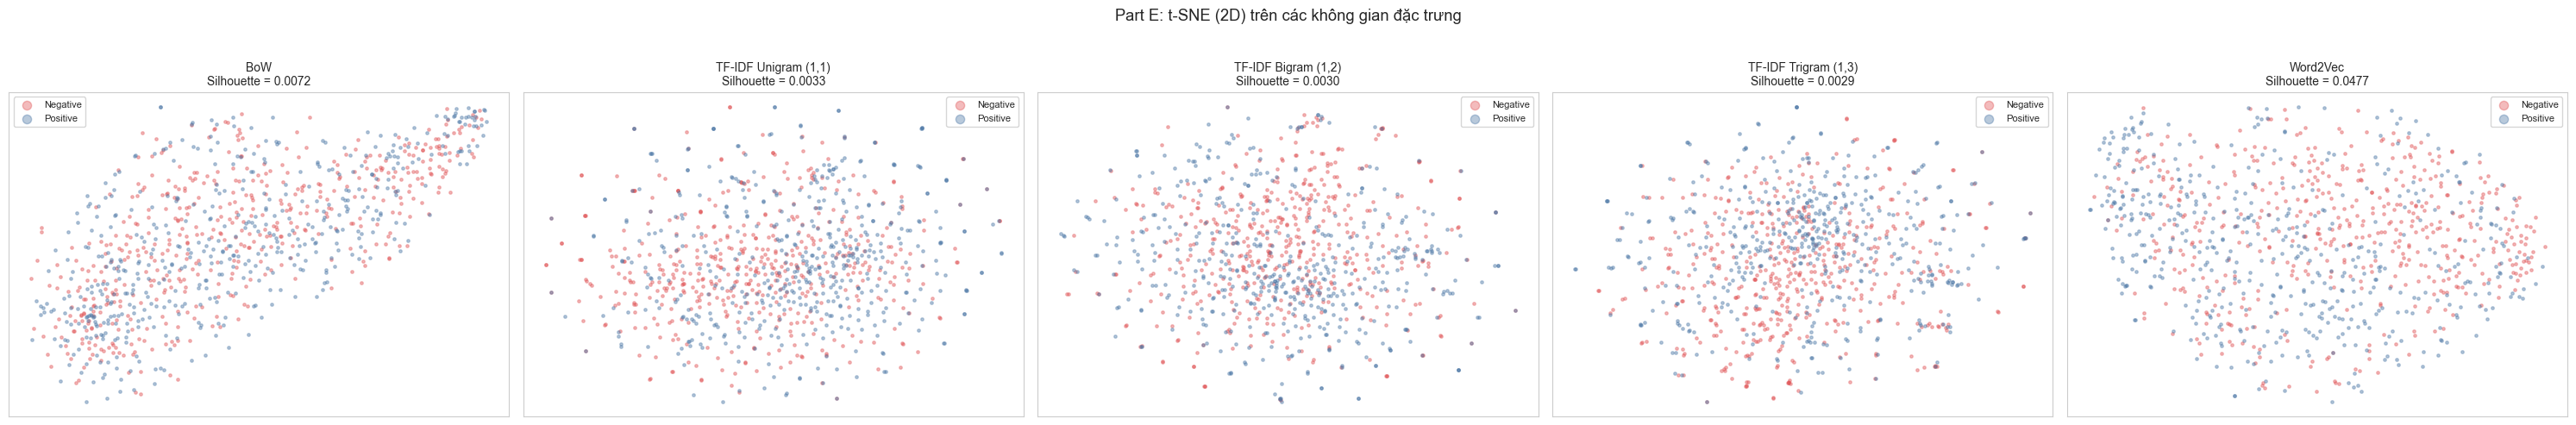

In [35]:
def run_tsne(X, sample_idx, label, y_sub):
    if hasattr(X, 'toarray'):
        Xs = X[sample_idx].toarray()
    else:
        Xs = X[sample_idx]
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
    return tsne.fit_transform(Xs)

TSNE_N = 1000
tsne_idx = rng.choice(len(y), size=TSNE_N, replace=False)
y_tsne = y[tsne_idx]

tsne_data = {}
for name, X in feature_spaces_e:
    tsne_data[name] = run_tsne(X, tsne_idx, name, y_tsne)

fig, axes = plt.subplots(1, len(feature_spaces_e), figsize=(30, 5))
fig.suptitle("Part E: t-SNE (2D) trên các không gian đặc trưng\n")

palette = {1: "#4e79a7", 0: "#e15759"}
labels_map = {1: "Positive", 0: "Negative"}

for ax, (name, emb) in zip(axes, tsne_data.items()):
    sil = sil_results[name]
    for cls in [0, 1]:
        mask = y_tsne == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=palette[cls], label=labels_map[cls],
                   alpha=0.4, s=6)
    ax.set_title(f"{name}\nSilhouette = {sil:.4f}", fontsize=10)
    ax.legend(markerscale=3, fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

#### E.3 Phân tích kết quả

Bảng tổng hợp kết quả:

| Phương pháp | Số chiều | Loại ma trận | Sparsity Ratio | Cosine Similarity (Cùng lớp) | Cosine Similarity (Khác lớp) | Silhouette Score |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **BoW** | 10,000 | Sparse | 98.76% | 0.5254 | 0.5222 | 0.0072 |
| **TF-IDF Unigram (1,1)** | 10,000 | Sparse | 98.76% | 0.1321 | 0.1329 | 0.0033 |
| **TF-IDF Bigram (1,2)** | 10,000 | Sparse | 98.16% | 0.1093 | 0.1072 | 0.0029 |
| **TF-IDF Trigram (1,3)** | 10,000 | Sparse | 98.10% | 0.1074 | 0.1048 | 0.0029 |
| **Word2Vec** | 100 | Dense | 0.00% | 0.8638 | 0.8718 | 0.0477 |

Dựa vào các số liệu và biểu đồ trực quan, chúng ta có thể rút ra những đánh giá chi tiết như sau:

**1. Về số chiều và độ thưa của không gian đặc trưng:**
* **BoW và TF-IDF:** Các phương pháp dựa trên từ vựng rời rạc đều tạo ra không gian đặc trưng rất cao chiều (`10,000` chiều) và cực kỳ thưa. BoW và TF-IDF unigram có cùng mức sparsity là **98.76%**, trong khi khi mở rộng sang bigram và trigram, độ thưa giảm nhẹ xuống **98.16%** và **98.10%** vì mỗi văn bản kích hoạt thêm nhiều đặc trưng n-gram hơn.
* **Word2Vec:** Trái ngược với các biểu diễn sparse truyền thống, Word2Vec cho ra vector dense chỉ với **100 chiều** và gần như **không có phần tử 0**. Điều này cho thấy Word2Vec biểu diễn văn bản gọn hơn đáng kể, giúp giảm chi phí lưu trữ và tính toán so với BoW hay TF-IDF.

**2. Về độ tương đồng cosine giữa các văn bản:**
* **BoW:** Giá trị cosine similarity trung bình giữa các cặp văn bản cùng lớp và khác lớp lần lượt là **0.5254** và **0.5222**, gần như không có sự khác biệt đáng kể. Điều này cho thấy trong không gian BoW, các review positive và negative vẫn chồng lấn khá mạnh.
* **TF-IDF Unigram/Bigram/Trigram:** Các biến thể TF-IDF cho giá trị cosine similarity khá thấp. Cụ thể, Unigram đạt 0.1321 (cùng lớp) và 0.1329 (khác lớp). Khi mở rộng sang Bigram (0.1093 và 0.1072) và Trigram (0.1074 và 0.1048), các giá trị này tiếp tục giảm. Chênh lệch giữa các cặp cùng lớp và khác lớp ở cả ba biến thể là cực kỳ nhỏ (thậm chí ở Unigram, cặp khác lớp còn có độ tương đồng nhỉnh hơn), cho thấy khoảng cách góc giữa các review không có sự phân hóa rõ ràng theo nhãn cảm xúc.
* **Word2Vec:** Phương pháp này cho giá trị cosine rất cao ở cả hai nhóm (**0.8638** và **0.8718**), phản ánh việc các vector trung bình có xu hướng khá gần nhau trong không gian embedding. Tuy nhiên, chênh lệch giữa cùng lớp và khác lớp vẫn nhỏ, nên chỉ riêng cosine similarity chưa đủ để khẳng định khả năng tách lớp mạnh.

**3. Về khả năng tách lớp qua Silhouette Score và biểu đồ t-SNE:**
* Silhouette Score của các biểu diễn trong Part E nhìn chung vẫn khá thấp, cho thấy dữ liệu không hình thành các cụm tách biệt mạnh trong không gian đặc trưng.
* Word2Vec cho khả năng tách lớp tương đối tốt nhất với Silhouette Score đạt cao nhất ở mức 0.0477.

* BoW đạt mức 0.0072, có phần nhỉnh hơn so với các biến thể TF-IDF. Cụ thể, TF-IDF Unigram chỉ đạt 0.0033, và khi tăng lên Bigram/Trigram, điểm số giảm xuống mức 0.0029. Điều này cho thấy trong tập dữ liệu này, việc áp dụng trọng số TF-IDF và mở rộng n-gram không giúp cải thiện sự phân tách cụm mà còn làm cho biểu diễn không gian phân tán hơn so với BoW thuần túy.
* Trên biểu đồ t-SNE 2D, sự chồng lấn mạnh giữa hai lớp positive và negative sẽ được thể hiện rõ ràng ở tất cả các biểu diễn, hoàn toàn nhất quán với các chỉ số hình học thấp đã tính toán ở trên.

**Đánh giá chung:**
Các phương pháp vector hóa truyền thống như **BoW** và **TF-IDF** có ưu điểm là đơn giản, dễ triển khai và giữ được thông tin tần suất từ/ngữ, nhưng tạo ra không gian rất thưa và chưa thể hiện khả năng tách lớp tốt khi quan sát bằng các thước đo hình học. Trong khi đó, **Word2Vec** tạo biểu diễn cô đọng, dense và cho Silhouette Score tốt hơn, cho thấy lợi thế về mặt biểu diễn ngữ nghĩa cục bộ của từ. Tuy nhiên, với cách gộp vector bằng trung bình, Word2Vec vẫn chưa đủ mạnh để tách biệt hoàn toàn hai lớp sentiment.
* Nếu ưu tiên **mô hình đơn giản, dễ diễn giải và phù hợp với pipeline cổ điển**, **BoW/TF-IDF** vẫn là lựa chọn hợp lý.
* Nếu ưu tiên **biểu diễn gọn hơn và phản ánh ngữ nghĩa tốt hơn**, **Word2Vec** là hướng tiếp cận phù hợp hơn, dù vẫn cần kết hợp với mô hình học có giám sát để khai thác hiệu quả.


---

## Part F. Biểu diễn ngữ nghĩa bằng Sentence Transformer

### F.1 Lý thuyết: Biểu diễn ngữ nghĩa bằng Sentence Transformer

Trong khi TF-IDF biểu diễn văn bản dựa trên sự khớp nối từ vựng và tạo ra ma trận thưa, các mô hình ngôn ngữ lớn dựa trên kiến trúc Transformer cung cấp một cách tiếp cận hoàn toàn khác: biểu diễn ngữ nghĩa dày đặc.

#### 1. Sentence Transformer

**Sentence Transformer** là một biến thể của mạng nơ-ron Transformer (như BERT, RoBERTa) được tinh chỉnh bằng kiến trúc mạng Siamese để tạo ra các vector nhúng cho toàn bộ câu hoặc đoạn văn bản một cách hiệu quả.

* **all-MiniLM-L6-v2:** Là một mô hình pretrained phổ biến thuộc thư viện `sentence-transformers`. Nó phiên bản thu gọn nhưng vẫn giữ được hiệu năng cao. Mô hình này ánh xạ các câu hoặc đoạn văn vào một không gian vector dày đặc có số chiều cố định (thường là 384 chiều).
* **Đặc điểm:** Không giống như TF-IDF đếm từ độc lập, Sentence Transformer đọc toàn bộ câu để nắm bắt ngữ cảnh, thứ tự từ và ý nghĩa sâu xa.

#### 2. So sánh chất lượng phân cụm

Sử dụng thuật toán **K-Means** để phân cụm và **Silhouette Score** để đánh giá:

* **Trên không gian TF-IDF:** K-Means thường gặp khó khăn do "curse of dimensionality". Ma trận TF-IDF có số chiều rất lớn (hàng chục nghìn) và thưa thớt, khiến cho khoảng cách (như Euclidean distance được dùng trong K-Means) mất đi nhiều ý nghĩa phân biệt. Silhouette score thường thấp do các cụm bị phân tán.
* **Trên không gian Sentence Transformer:** Các vector có số chiều thấp (vd: 384) và dày đặc. Không gian này được tối ưu hóa sao cho khoảng cách giữa các vector phản ánh chính xác sự khác biệt về ngữ nghĩa. Do đó, K-Means thường tạo ra các cụm chặt chẽ và tách biệt rõ ràng hơn, dẫn đến Silhouette score cao hơn.

#### 3. So sánh hiệu năng phân loại

Sử dụng **Linear SVM** để đánh giá:

* **Với TF-IDF:** Linear SVM hoạt động khá tốt trên không gian đặc trưng thưa và chiều cao của TF-IDF. Nếu bài toán phân loại phụ thuộc nhiều vào các từ khóa cụ thể (ví dụ: review có từ "tệ", "tuyệt vời"), TF-IDF có thể đạt hiệu năng rất cạnh tranh.
* **Với Sentence Transformer:** Cung cấp hiệu năng vượt trội trong các trường hợp dữ liệu phức tạp, cần suy luận ngữ cảnh thay vì chỉ tìm từ khóa. Vì không gian đặc trưng nhỏ gọn, thời gian huấn luyện SVM trên embeddings thường nhanh hơn và ít bị overfitting hơn so với không gian BoW/TF-IDF nguyên thủy.

#### 4. Giải thích sự khác biệt về mặt ngữ nghĩa

Sự khác biệt cốt lõi giữa TF-IDF và Sentence Transformer nằm ở khả năng hiểu **ngữ nghĩa** so với **cú pháp/từ vựng**:

* **Vấn đề từ đồng nghĩa và diễn đạt khác:** * Xét 2 câu: $S_1 =$ "Chiếc xe ô tô rất nhanh" và $S_2 =$ "Chiếc xế hộp có tốc độ cực khủng".
    * **TF-IDF:** Tính Cosine Similarity giữa $S_1$ và $S_2$ có thể bằng $0$ (hoặc rất thấp) vì chúng không có chung từ vựng nào.
    * **Sentence Transformer:** Nhận diện được cả hai câu đều mang ý nghĩa tương đồng (nói về phương tiện di chuyển nhanh), do đó Cosine Similarity giữa 2 vector nhúng sẽ rất cao.
* **Vấn đề ngữ cảnh và từ nhiều nghĩa (Polysemy):** Sentence Transformer tạo ra vector cho một từ/câu dựa trên ngữ cảnh xung quanh nó (ví dụ: phân biệt được từ "đường" trong "đường ăn" và "con đường"), điều mà TF-IDF hoàn toàn bất lực.

### F.2 Code cài đặt

In [31]:
SUBSET_N = 5000
rng_f = np.random.default_rng(0)
f_idx = rng_f.choice(len(y), size=SUBSET_N, replace=False)
y_f = y[f_idx]
texts_f = TEXT_COL.iloc[f_idx].tolist()

# TF-IDF subset
print("TF-IDF subset")
tfidf_f_vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X_tfidf_f = tfidf_f_vec.fit_transform(texts_f)
print(f"  Shape: {X_tfidf_f.shape}")

# Sentence Transformer
print("\nSentence Transformer (all-MiniLM-L6-v2)")
print("  Đang load model và tạo embeddings")
st_model = SentenceTransformer('all-MiniLM-L6-v2')
X_st = st_model.encode(texts_f, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f"  Shape: {X_st.shape}")

TF-IDF subset
  Shape: (5000, 10000)

Sentence Transformer (all-MiniLM-L6-v2)
  Đang load model và tạo embeddings


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

  Shape: (5000, 384)


K-Means Clustering & Silhouette Score

In [32]:
# Lấy mẫu nhỏ để Silhouette không quá chậm
SIL_N = 2000
sil_idx_f = rng_f.choice(SUBSET_N, size=SIL_N, replace=False)
y_sil_f = y_f[sil_idx_f]

km_results = {}
for name, X in [("TF-IDF", X_tfidf_f), ("Sentence Transformer", X_st)]:
    if hasattr(X, 'toarray'):
        Xs = normalize(X[sil_idx_f].toarray())
    else:
        Xs = normalize(X[sil_idx_f])

    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    km.fit(Xs)
    sil = silhouette_score(Xs, km.labels_, metric='euclidean')
    km_results[name] = {"Silhouette (K-Means)": round(sil, 4)}
    print(f"  {name:<30}  Silhouette (KMeans) = {sil:.4f}")


  TF-IDF                          Silhouette (KMeans) = 0.0049
  Sentence Transformer            Silhouette (KMeans) = 0.0335


Linear SVM — 5-fold Cross-Validation

In [33]:
svm_results = []
for name, X in [("TF-IDF", X_tfidf_f), ("Sentence Transformer", X_st)]:
    if hasattr(X, 'toarray'):
        Xd = X.toarray()
    else:
        Xd = X
    svm = LinearSVC(max_iter=2000, random_state=42)
    scores = cross_val_score(svm, Xd, y_f, cv=5, scoring='accuracy')
    svm_results.append({
        "Phương pháp"  : name,
        "Accuracy TB"  : round(scores.mean(), 4),
        "Std"          : round(scores.std(),  4),
    })
    print(f"  {name:<30}  Acc = {scores.mean():.4f} ± {scores.std():.4f}")

svm_df = pd.DataFrame(svm_results).set_index("Phương pháp")
print("\nBẢNG TỔNG HỢP Linear SVM (5-fold CV):")
svm_df

  TF-IDF                          Acc = 0.8546 ± 0.0078
  Sentence Transformer            Acc = 0.8180 ± 0.0074

BẢNG TỔNG HỢP Linear SVM (5-fold CV):


,Accuracy TB,Std
Phương pháp,,
TF-IDF,0.8546,0.0078
Sentence Transformer,0.8180,0.0074


#### Trực quan hóa

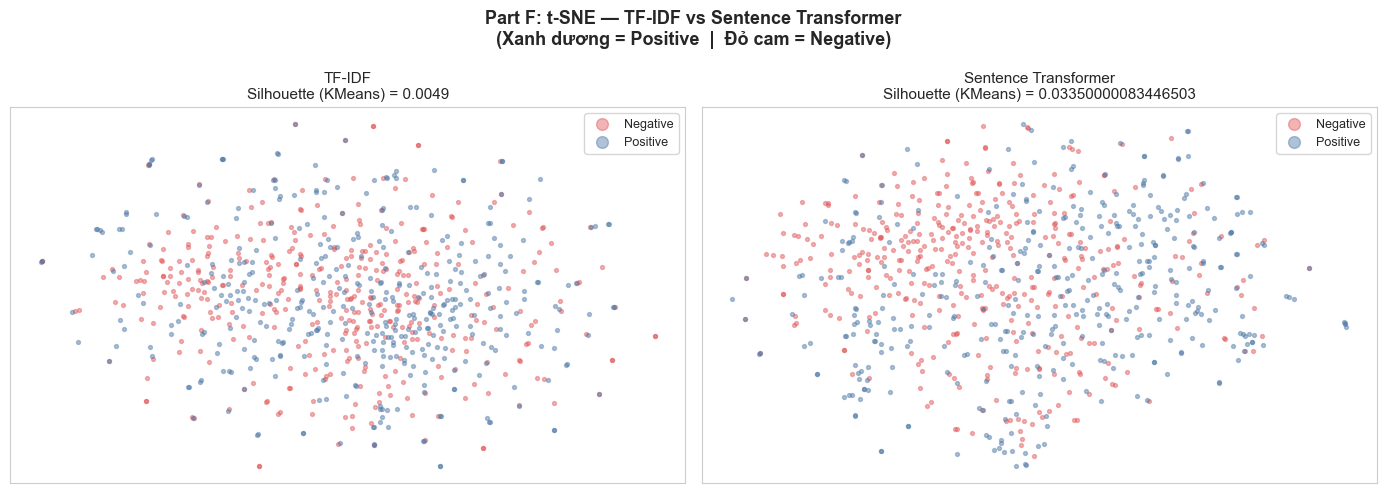

In [34]:
TSNE_N_F = 800
tsne_idx_f = rng_f.choice(SUBSET_N, size=TSNE_N_F, replace=False)
y_tsne_f = y_f[tsne_idx_f]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part F: t-SNE — TF-IDF vs Sentence Transformer\n"
             "(Xanh dương = Positive  |  Đỏ cam = Negative)",
             fontsize=13, fontweight='bold')

palette_f = {1: "#4e79a7", 0: "#e15759"}
labels_map_f = {1: "Positive", 0: "Negative"}

for ax, (name, X) in zip(axes, [("TF-IDF", X_tfidf_f), ("Sentence Transformer", X_st)]):
    if hasattr(X, 'toarray'):
        Xs = X[tsne_idx_f].toarray()
    else:
        Xs = X[tsne_idx_f]
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
    emb = tsne.fit_transform(Xs)
    sil_km = km_results.get(name, {}).get("Silhouette (K-Means)", "N/A")
    for cls in [0, 1]:
        mask = y_tsne_f == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=palette_f[cls], label=labels_map_f[cls],
                   alpha=0.45, s=8)
    ax.set_title(f"{name}\nSilhouette (KMeans) = {sil_km}", fontsize=11)
    ax.legend(markerscale=3, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


#### F.3 Phân tích kết quả

Bảng tổng hợp kết quả:

| Phương pháp | Số chiều biểu diễn | Silhouette Score (K-Means) | Accuracy TB (Linear SVM, 5-fold CV) | Độ lệch chuẩn (Std) |
| :--- | :--- | :--- | :--- | :--- |
| **TF-IDF** | 10,000 | 0.0049 | 85.46% | 0.0078 |
| **Sentence Transformer** | 384 | 0.0335 | 81.80% | 0.0074 |

Dựa vào các số liệu và biểu đồ trực quan, chúng ta có thể rút ra những đánh giá chi tiết như sau:

**1. Về chất lượng phân cụm và cấu trúc không gian ngữ nghĩa:**
* **TF-IDF:** Biểu diễn TF-IDF tạo ra không gian đặc trưng rất cao chiều (`10,000` chiều) và chủ yếu dựa trên mức độ xuất hiện của từ/ngữ. Kết quả **Silhouette Score chỉ đạt 0.0049**, cho thấy các điểm dữ liệu gần như không hình thành được các cụm tách biệt rõ ràng khi áp dụng K-Means. Điều này phản ánh hạn chế của TF-IDF trong việc nắm bắt ngữ nghĩa sâu hơn của câu, đặc biệt khi các review có thể dùng những từ khác nhau để diễn tả cùng một cảm xúc.
* **Sentence Transformer:** Trái ngược với TF-IDF, Sentence Transformer biểu diễn mỗi review bằng vector dense chỉ với **384 chiều**, nhưng chứa thông tin ngữ nghĩa phong phú hơn. Kết quả **Silhouette Score đạt 0.0335**, cao hơn đáng kể so với TF-IDF. Mặc dù giá trị này vẫn chưa lớn, nó cho thấy embedding ngữ nghĩa đã giúp các văn bản có nội dung gần nhau được đặt gần nhau hơn trong không gian vector, từ đó hỗ trợ quá trình phân cụm tốt hơn.

**2. Về hiệu năng phân loại với Linear SVM:**
* **TF-IDF** đạt **độ chính xác trung bình 85.46%**, cao hơn rõ rệt so với **Sentence Transformer (81.80%)**. Điều này cho thấy trong bài toán phân loại cảm xúc trên IMDB, đặc trưng từ vựng bề mặt vẫn là tín hiệu rất mạnh đối với bộ phân loại tuyến tính như Linear SVM.
* Độ lệch chuẩn của hai phương pháp khá tương đương nhau (`0.0078` với TF-IDF và `0.0074` với Sentence Transformer), cho thấy cả hai mô hình đều có mức ổn định tương đối tốt qua 5 folds. Tuy nhiên, TF-IDF vẫn nhỉnh hơn về hiệu năng tổng thể.
* Kết quả này cũng cho thấy một điểm quan trọng: biểu diễn ngữ nghĩa tốt hơn chưa chắc sẽ dẫn đến độ chính xác phân loại cao hơn trong mọi trường hợp. Với tập IMDB, nhiều từ khóa sentiment như “good”, “bad”, “excellent”, “boring”,... xuất hiện khá trực tiếp, nên TF-IDF có thể khai thác rất hiệu quả.

**3. Về trực quan hóa t-SNE và ý nghĩa ngữ nghĩa:**
* Trên biểu đồ t-SNE, **Sentence Transformer** thường cho cấu trúc phân bố “mượt” và có xu hướng gom nhóm theo ngữ nghĩa tốt hơn TF-IDF. Điều này phù hợp với bản chất của embedding pretrained, nơi các câu có ý nghĩa tương đồng sẽ có xu hướng nằm gần nhau hơn ngay cả khi không dùng cùng từ vựng.
* Trong khi đó, **TF-IDF** thường tạo ra các điểm dữ liệu phân tán hơn vì biểu diễn phụ thuộc nhiều vào sự trùng khớp từ bề mặt. Do đó, dù đạt độ chính xác phân loại cao hơn, không gian TF-IDF lại kém thuận lợi hơn cho các tác vụ không giám sát như phân cụm hay trực quan hóa ngữ nghĩa.

**Đánh giá chung:**
So sánh giữa hai phương pháp cho thấy mỗi cách biểu diễn có một thế mạnh riêng.
* **Sentence Transformer** thể hiện ưu thế rõ rệt về mặt **biểu diễn ngữ nghĩa** và **chất lượng phân cụm**, thể hiện qua Silhouette Score cao hơn và không gian embedding có cấu trúc tốt hơn.
* **TF-IDF** lại vượt trội hơn về **hiệu năng phân loại với Linear SVM**, chứng tỏ rằng trong bài toán sentiment analysis trên IMDB, các tín hiệu từ vựng trực tiếp vẫn rất hữu ích cho mô hình tuyến tính.

Vì vậy:
* Nếu ưu tiên **phân loại văn bản với mô hình đơn giản, nhanh và hiệu quả**, **TF-IDF** là lựa chọn phù hợp hơn.
* Nếu ưu tiên **biểu diễn ngữ nghĩa, phân cụm, truy hồi hoặc tái sử dụng embedding cho các tác vụ NLP khác**, **Sentence Transformer** là hướng tiếp cận mạnh hơn và hiện đại hơn.
